In [ ]:
# CELL 1: Install required packages
!pip install torch torchvision scikit-learn pandas numpy pillow tqdm timm seaborn matplotlib optuna --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 15.9 MB/s eta 0:00:00


In [ ]:
# CELL 2: Imports (exactly as in your notebook, plus plotting/metric extras)
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import timm  # real DarkNet53 lives here

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate, train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, label_binarize
from sklearn.feature_selection import chi2, SelectKBest
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Imports OK. CUDA available:", torch.cuda.is_available())


Imports OK. CUDA available: True


In [ ]:
# CELL 3: Mount Google Drive and stage the dataset
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [ ]:
!cp "/content/drive/MyDrive/Samester Minor Project/OCTDL (1).zip" /content/

In [ ]:
# !unzip -q -o OCTDL.zip -d /content/data/
!unzip OCTDL.zip  -d /content/data/

Archive:  OCTDL.zip
   creating: /content/data/OCTDL/
   creating: /content/data/OCTDL/AMD/
  inflating: /content/data/OCTDL/AMD/amd_1047099_1.jpg  
  inflating: /content/data/OCTDL/AMD/amd_1047099_2.jpg  
  inflating: /content/data/OCTDL/AMD/amd_1047099_3.jpg  
  inflating: /content/data/OCTDL/AMD/amd_1047099_4.jpg  
  inflating: /content/data/OCTDL/AMD/amd_1084498_1.jpg  
  inflating: /content/data/OCTDL/AMD/amd_1084498_3.jpg  
  inflating: /content/data/OCTDL/AMD/amd_1096590_1.jpg  
  inflating: /content/data/OCTDL/AMD/amd_1096590_2.jpg  
  inflating: /content/data/OCTDL/AMD/amd_1096590_3.jpg  
  inflating: /content/data/OCTDL/AMD/amd_1096590_4.jpg  
  inflating: /content/data/OCTDL/AMD/amd_1096590_5.jpg  
  inflating: /content/data/OCTDL/AMD/amd_1101816_1.jpg  
  inflating: /content/data/OCTDL/AMD/amd_1101816_2.jpg  
  inflating: /content/data/OCTDL/AMD/amd_1101816_3.jpg  
  inflating: /content/data/OCTDL/AMD/amd_1101816_4.jpg  
  inflating: /content/data/OCTDL/AMD/amd_1131743_1.jp

In [ ]:
!cp "/content/drive/MyDrive/Samester Minor Project/OCTDL_labels (1).csv" /content/data/
print("Dataset staged at /content/data/")

Dataset staged at /content/data/


In [ ]:
# CELL 4: Configuration (identical to your notebook)
DATASET_ROOT = "/content/data/OCTDL"
CSV_PATH = "/content/data/OCTDL_labels (1).csv"

IMAGE_SIZE = 224
N_PATCHES = 4
BATCH_SIZE = 16

# INCA search: full step=1 sweep over the paper's specified range (Algorithm 1,
# Section 3.2.3: "for s = 100 to 500 do" -> every integer, 401 values).
INCA_RANGE = range(100, 501, 1)

CHI2_TOP_K = 300
N_FOLDS = 10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Disease label -> integer class mapping
CLASS7_MAP = {"AMD": 0, "DME": 1, "ERM": 2, "NO": 3, "RAO": 4, "RVO": 5, "VID": 6}
CLASS2_MAP = {"AMD": 1, "DME": 1, "ERM": 1, "NO": 0, "RAO": 1, "RVO": 1, "VID": 1}

LABEL_NAMES_7 = ["AMD", "DME", "ERM", "NO", "RAO", "RVO", "VID"]
LABEL_NAMES_2 = ["NO (Normal)", "Diseased"]

print("Device:", DEVICE)


Device: cuda


In [ ]:
# CELL 5: Dataset loader (identical to your notebook's load_dataset)
def load_dataset(csv_path, dataset_root):
    print("=" * 60)
    print("STEP 1: Loading Dataset")
    print("=" * 60)

    df = pd.read_csv(csv_path)
    print(f" CSV loaded : {len(df)} rows")
    print(f" Disease counts:\n{df['disease'].value_counts().to_string()}")

    image_paths, labels_7, labels_2 = [], [], []
    missing = 0

    for _, row in df.iterrows():
        disease = str(row["disease"]).strip()
        file_name = str(row["file_name"]).strip()
        found = False
        for ext in [".jpg", ".jpeg", ".png", ".bmp"]:
            candidate = os.path.join(dataset_root, disease, file_name + ext)
            if os.path.exists(candidate):
                image_paths.append(candidate)
                labels_7.append(CLASS7_MAP.get(disease, -1))
                labels_2.append(CLASS2_MAP.get(disease, -1))
                found = True
                break
        if not found:
            missing += 1

    labels_7 = np.array(labels_7)
    labels_2 = np.array(labels_2)
    valid = (labels_7 >= 0) & (labels_2 >= 0)
    image_paths = [p for p, v in zip(image_paths, valid) if v]
    labels_7 = labels_7[valid]
    labels_2 = labels_2[valid]

    print(f" Images found   : {len(image_paths)}")
    print(f" Images missing : {missing}")
    return image_paths, labels_7, labels_2


In [ ]:
# CELL 6: Run the loader
image_paths, labels_7, labels_2 = load_dataset(CSV_PATH, DATASET_ROOT)
print("Total images:", len(image_paths))


STEP 1: Loading Dataset
 CSV loaded : 2064 rows
 Disease counts:
disease
AMD    1231
NO      332
ERM     155
DME     147
RVO     101
VID      76
RAO      22
 Images found   : 2064
 Images missing : 0
Total images: 2064


In [ ]:
# CELL 7: Preprocessing transform (resize + ImageNet normalization)
def get_transform():
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225])
    ])

def load_image(path):
    return Image.open(path).convert("RGB")


In [ ]:
# CELL 8: Patch division (splits each 224x224 image into N vertical strips)
def make_patches(img_tensor, n_patches=N_PATCHES):
    W = img_tensor.shape[-1]
    patch_w = W // n_patches
    return [img_tensor[:, :, i * patch_w:(i + 1) * patch_w] for i in range(n_patches)]

def resize_patch(patch_tensor):
    p = patch_tensor.unsqueeze(0)
    p = nn.functional.interpolate(p, size=(224, 224), mode="bilinear", align_corners=False)
    return p.squeeze(0)


In [ ]:
# CELL 9: Feature extractor wrapping the three pretrained backbones (identical to your notebook)
class FeatureExtractor(nn.Module):
    """
    mobilenetv2 -> GAP=1280, FC=1000
    darknet53   -> GAP=1024, FC=1000 (real DarkNet53, via timm)
    densenet201 -> GAP=1920, FC=1000
    """
    def __init__(self, model_name):
        super().__init__()
        self.model_name = model_name

        if model_name == "mobilenetv2":
            base = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
            self.features = base.features
            self.gap = nn.AdaptiveAvgPool2d((1, 1))
            self.fc = base.classifier
        elif model_name == "darknet53":
            self.backbone = timm.create_model("darknet53", pretrained=True)
            self.gap = nn.AdaptiveAvgPool2d((1, 1))
        elif model_name == "densenet201":
            base = models.densenet201(weights=models.DenseNet201_Weights.IMAGENET1K_V1)
            self.features = base.features
            self.fc_layer = base.classifier

        self.eval()
        for p in self.parameters():
            p.requires_grad = False

    def forward(self, x):
        if self.model_name == "mobilenetv2":
            feat_map = self.features(x)
            gap_feat = self.gap(feat_map).view(x.size(0), -1)
            fc_feat = self.fc(gap_feat)
        elif self.model_name == "darknet53":
            feat_map = self.backbone.forward_features(x)
            gap_feat = self.gap(feat_map).view(x.size(0), -1)
            fc_feat = self.backbone(x)
        elif self.model_name == "densenet201":
            feat_map = self.features(x)
            gap_feat = nn.functional.relu(feat_map, inplace=False)
            gap_feat = nn.functional.adaptive_avg_pool2d(gap_feat, (1, 1)).view(x.size(0), -1)
            fc_feat = self.fc_layer(gap_feat)

        combined = torch.cat([gap_feat, fc_feat], dim=1)
        return combined.cpu().numpy()


In [ ]:
# CELL 10: Parameter-count helper (additive - for the "number of parameters" requirement)
def count_parameters(model_name):
    extractor = FeatureExtractor(model_name)
    total_params = sum(p.numel() for p in extractor.parameters())
    trainable_params = sum(p.numel() for p in extractor.parameters() if p.requires_grad)
    return total_params, trainable_params


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 115MB/s]


model.safetensors: reconstructing file:   0%|          |  0.00B /  167MB            

model.safetensors: downloading bytes:           |  0.00B            

Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth


100%|██████████| 77.4M/77.4M [00:00<00:00, 199MB/s]


      Model  Total Params  Trainable Params  Total Params (M)
mobilenetv2       3504872                 0              3.50
  darknet53      41609928                 0             41.61
densenet201      20013928                 0             20.01


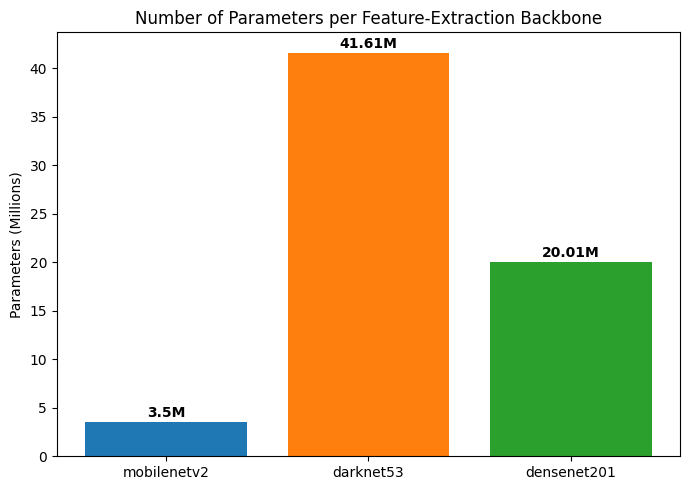

In [ ]:
# CELL 11: Print + plot parameter counts for every backbone used in the pipeline
param_rows = []
for name in ["mobilenetv2", "darknet53", "densenet201"]:
    total, trainable = count_parameters(name)
    param_rows.append({"Model": name, "Total Params": total,
                        "Trainable Params": trainable,
                        "Total Params (M)": round(total / 1e6, 2)})

param_df = pd.DataFrame(param_rows)
print(param_df.to_string(index=False))

plt.figure(figsize=(7, 5))
bars = plt.bar(param_df["Model"], param_df["Total Params (M)"], color=["#1f77b4", "#ff7f0e", "#2ca02c"])
for b, v in zip(bars, param_df["Total Params (M)"]):
    plt.text(b.get_x() + b.get_width() / 2, v + 0.5, f"{v}M", ha="center", fontweight="bold")
plt.ylabel("Parameters (Millions)")
plt.title("Number of Parameters per Feature-Extraction Backbone")
plt.tight_layout()
plt.savefig("backbone_parameter_counts.png", dpi=150)
plt.show()


In [ ]:
# CELL 12: Feature extraction (identical to your notebook's extract_all_features)
def extract_all_features(image_paths, model_name, n_patches=N_PATCHES, batch_size=BATCH_SIZE):
    save_path = f"{model_name}_features.npy"
    if os.path.exists(save_path):
        print(f" {model_name}: loading cached {save_path}")
        return np.load(save_path)

    print(f" Extracting features with {model_name}...")
    extractor = FeatureExtractor(model_name).to(DEVICE)
    transform = get_transform()
    all_feats = []

    for i in tqdm(range(0, len(image_paths), batch_size), desc=f" {model_name}"):
        batch_paths = image_paths[i:i + batch_size]
        for path in batch_paths:
            img = load_image(path)
            tensor = transform(img)
            with torch.no_grad():
                orig_feat = extractor(tensor.unsqueeze(0).to(DEVICE))
            patches = make_patches(tensor, n_patches)
            feats_list = [orig_feat]
            for patch in patches:
                resized = resize_patch(patch)
                with torch.no_grad():
                    pf = extractor(resized.unsqueeze(0).to(DEVICE))
                feats_list.append(pf)
            row = np.sum(np.vstack(feats_list), axis=0, keepdims=True)
            all_feats.append(row)

    result = np.vstack(all_feats)
    np.save(save_path, result)
    print(f" Saved: {save_path} shape={result.shape}")
    return result


In [ ]:
# CELL 13: Run feature extraction for the 3 backbones (shared by both cases)
print("=" * 60)
print("STEP 4: Feature Extraction")
print("=" * 60)
F1 = extract_all_features(image_paths, "mobilenetv2")
F2 = extract_all_features(image_paths, "darknet53")
F3 = extract_all_features(image_paths, "densenet201")
print(f"F1={F1.shape}  F2={F2.shape}  F3={F3.shape}")


STEP 4: Feature Extraction
 Extracting features with mobilenetv2...


 mobilenetv2: 100%|██████████| 129/129 [01:35<00:00,  1.36it/s]


 Saved: mobilenetv2_features.npy shape=(2064, 2280)
 Extracting features with darknet53...


 darknet53: 100%|██████████| 129/129 [03:15<00:00,  1.52s/it]


 Saved: darknet53_features.npy shape=(2064, 2024)
 Extracting features with densenet201...


 densenet201: 100%|██████████| 129/129 [05:24<00:00,  2.51s/it]

 Saved: densenet201_features.npy shape=(2064, 2920)
F1=(2064, 2280)  F2=(2064, 2024)  F3=(2064, 2920)


In [ ]:
# CELL 14: INCA (Iterative NCA) feature selection - identical to your notebook
def inca_feature_selection(X, y, search_range=INCA_RANGE, label=""):
    tag = f" [{label}]" if label else ""
    print(f"INCA{tag}: normalizing {X.shape[1]} features...")
    scaler = MinMaxScaler()
    X_norm = scaler.fit_transform(X)

    n_comp = min(50, X.shape[1], X.shape[0] - 1)
    print(f"INCA{tag}: running NCA with n_components={n_comp}...")
    nca = NeighborhoodComponentsAnalysis(n_components=n_comp, random_state=42, max_iter=200)
    nca.fit(X_norm, y)

    importance = np.linalg.norm(nca.components_, axis=0)
    sorted_idx = np.argsort(importance)[::-1]

    knn = KNeighborsClassifier(n_neighbors=5)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    sizes = list(search_range)

    print(f"INCA{tag}: full sweep over {len(sizes)} sizes ({sizes[0]}-{sizes[-1]}, step=1)...")
    best_s, best_err = sizes[0], float("inf")
    for s in tqdm(sizes, desc=f" INCA{tag}", leave=False):
        X_sub = X_norm[:, sorted_idx[:s]]
        preds = cross_val_predict(knn, X_sub, y, cv=cv)
        err = 1.0 - accuracy_score(y, preds)
        if err < best_err:
            best_err, best_s = err, s

    print(f"INCA{tag}: optimal count = {best_s} (CV error = {best_err:.4f})")
    X_selected = X_norm[:, sorted_idx[:best_s]]
    return X_selected, best_s, sorted_idx[:best_s]


In [ ]:
# CELL 15: Chi-Square feature selection helper (kept from your notebook - used
# internally for reference / the alternate quick-load path, not the main flow)
def chi2_feature_selection(X_merged, y, k=CHI2_TOP_K):
    print(f"Chi2: selecting top {k} from {X_merged.shape[1]} features...")
    X_nn = np.clip(X_merged, 0, None)
    k_actual = min(k, X_nn.shape[1])
    selector = SelectKBest(chi2, k=k_actual)
    X_final = selector.fit_transform(X_nn, y)
    print(f"Chi2: output shape = {X_final.shape}")
    return X_final, selector


In [ ]:
# CELL 16: THE ACTUAL CLASSIFIER YOUR NOTEBOOK USES IN main()
# This is joint_search_and_evaluate, reproduced exactly from your uploaded
# .ipynb (Optuna-tuned SVM: chi2_k, C, coef0, gamma, per-class weight power,
# and - for binary - a decision threshold, all searched jointly).
# ONLY ADDITION vs your original: it also returns y_proba (the predicted
# probabilities), which the original didn't return but is needed for the
# ROC/PR plots below. The accuracy-determining logic (y_pred) is untouched.
def make_class_weight_dict(y, power):
    """power=1.0 == sklearn 'balanced'. >1 pushes minority classes harder,
    <1 is gentler. Tuning this instead of hardcoding None/'balanced' is
    the single biggest lever for imbalanced classes like RAO/VID."""
    classes = np.unique(y)
    base_w = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    w = base_w ** power
    return {c: wi for c, wi in zip(classes, w)}


def joint_search_and_evaluate(F_merge, y, label_names, case_name="7-class",
                               k_low=100, k_high=None, n_trials=150,
                               search_cv_folds=5):
    is_binary = len(np.unique(y)) == 2
    if k_high is None:
        k_high = F_merge.shape[1]
    search_cv = StratifiedKFold(n_splits=search_cv_folds, shuffle=True, random_state=42)

    def objective(trial):
        k = trial.suggest_int("chi2_k", k_low, k_high)
        C = trial.suggest_float("C", 1e-3, 1e2, log=True)
        coef0 = trial.suggest_float("coef0", 0.0, 3.0)
        gamma = trial.suggest_float("gamma", 1e-5, 3e0, log=True)
        weight_power = trial.suggest_float("weight_power", 0.1, 3.0)

        X_nn = np.clip(F_merge, 0, None)
        X_k = SelectKBest(chi2, k=k).fit_transform(X_nn, y)
        cw = make_class_weight_dict(y, weight_power)

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(kernel="poly", degree=2, C=C, coef0=coef0,
                        gamma=gamma, class_weight=cw,
                        probability=is_binary, random_state=42))
        ])

        if is_binary:
            threshold = trial.suggest_float("threshold", 0.25, 0.75)
            probs = cross_val_predict(pipe, X_k, y, cv=search_cv,
                                       method="predict_proba", n_jobs=-1)
            pos_idx = list(np.unique(y)).index(1)
            preds = (probs[:, pos_idx] >= threshold).astype(int)
        else:
            preds = cross_val_predict(pipe, X_k, y, cv=search_cv, n_jobs=-1)
        return accuracy_score(y, preds)

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42, multivariate=True, n_startup_trials=20)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    best = study.best_params
    print(f"BEST PARAMS: {best}  |  5-fold CV acc: {study.best_value*100:.2f}%")

    # Rebuild with best params, evaluate with the real 10-fold CV
    X_nn = np.clip(F_merge, 0, None)
    X_final = SelectKBest(chi2, k=best["chi2_k"]).fit_transform(X_nn, y)
    cw_final = make_class_weight_dict(y, best["weight_power"])
    final_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="poly", degree=2, C=best["C"], coef0=best["coef0"],
                    gamma=best["gamma"], class_weight=cw_final,
                    probability=True, random_state=42))
    ])
    cv10 = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

    # Probabilities (needed for ROC / PR curves) - computed the same way for
    # both cases so the plots below have a common source.
    y_proba = cross_val_predict(final_pipe, X_final, y, cv=cv10,
                                 method="predict_proba", n_jobs=-1)

    if is_binary:
        pos_idx = list(np.unique(y)).index(1)
        y_pred = (y_proba[:, pos_idx] >= best["threshold"]).astype(int)
    else:
        y_pred = cross_val_predict(final_pipe, X_final, y, cv=cv10, n_jobs=-1)

    acc = accuracy_score(y, y_pred) * 100
    print(f"Overall Accuracy (10-fold, best config): {acc:.2f}%")

    results = {}
    for i, name in enumerate(label_names):
        y_b, yp_b = (y == i).astype(int), (y_pred == i).astype(int)
        TP = np.sum((y_b==1)&(yp_b==1)); TN = np.sum((y_b==0)&(yp_b==0))
        FP = np.sum((y_b==0)&(yp_b==1)); FN = np.sum((y_b==1)&(yp_b==0))
        sen = TP/(TP+FN+1e-8)*100; spe = TN/(TN+FP+1e-8)*100
        pre = TP/(TP+FP+1e-8)*100; f1 = 2*sen*pre/(sen+pre+1e-8)
        geo = np.sqrt(sen*spe)
        results[name] = {"Sensitivity":sen,"Specificity":spe,"Precision":pre,
                          "F1-score":f1,"Geometric Mean":geo}
    results["Accuracy"] = acc
    results["Best_params"] = best
    results["X_final_shape"] = X_final.shape

    return y_pred, y_proba, results, X_final


def get_fold_scores_from_best(X_final, y, best_params):
    """Per-fold train/test accuracy using the Optuna-selected best pipeline -
    purely for visualization, does not affect the reported accuracy above."""
    cw = make_class_weight_dict(y, best_params["weight_power"])
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="poly", degree=2, C=best_params["C"], coef0=best_params["coef0"],
                    gamma=best_params["gamma"], class_weight=cw,
                    probability=True, random_state=42))
    ])
    cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    scores = cross_validate(pipe, X_final, y, cv=cv, return_train_score=True, n_jobs=-1)
    return scores["train_score"], scores["test_score"]


def get_binary_fold_scores(X_final, y, best_params):
    """Per-fold train/test accuracy for the BINARY case, computed the same
    way the final reported accuracy is computed - i.e. using the SVM's
    predicted probability plus the Optuna-selected decision threshold, not
    the default 0.5 cutoff. cross_validate()'s default .score() ignores the
    custom threshold, which is why a plain cross_validate-based test score
    (~97.19%) does not match the actual reported Overall Accuracy (97.63%).
    This function fixes that mismatch so the fold-level test scores are
    consistent with the real, threshold-aware predictions."""
    cw = make_class_weight_dict(y, best_params["weight_power"])
    threshold = best_params["threshold"]
    pos_idx = list(np.unique(y)).index(1)
    cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    train_scores, test_scores = [], []
    for train_idx, test_idx in cv.split(X_final, y):
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(kernel="poly", degree=2, C=best_params["C"], coef0=best_params["coef0"],
                        gamma=best_params["gamma"], class_weight=cw,
                        probability=True, random_state=42))
        ])
        pipe.fit(X_final[train_idx], y[train_idx])
        train_probs = pipe.predict_proba(X_final[train_idx])[:, pos_idx]
        test_probs = pipe.predict_proba(X_final[test_idx])[:, pos_idx]
        train_preds = (train_probs >= threshold).astype(int)
        test_preds = (test_probs >= threshold).astype(int)
        train_scores.append(accuracy_score(y[train_idx], train_preds))
        test_scores.append(accuracy_score(y[test_idx], test_preds))
    return np.array(train_scores), np.array(test_scores)


##Case 2: Binary classification

In [ ]:
# CELL 17: INCA feature selection - Binary labels
S1b, s1b, _ = inca_feature_selection(F1, labels_2, label="MobileNetV2-bin")
S2b, s2b, _ = inca_feature_selection(F2, labels_2, label="DarkNet53-bin")
S3b, s3b, _ = inca_feature_selection(F3, labels_2, label="DenseNet201-bin")
print(f"S1b={S1b.shape[1]}  S2b={S2b.shape[1]}  S3b={S3b.shape[1]}")


INCA [MobileNetV2-bin]: normalizing 2280 features...
INCA [MobileNetV2-bin]: running NCA with n_components=50...
INCA [MobileNetV2-bin]: full sweep over 401 sizes (100-500, step=1)...


INCA [MobileNetV2-bin]: optimal count = 101 (CV error = 0.0441)
INCA [DarkNet53-bin]: normalizing 2024 features...
INCA [DarkNet53-bin]: running NCA with n_components=50...
INCA [DarkNet53-bin]: full sweep over 401 sizes (100-500, step=1)...


INCA [DarkNet53-bin]: optimal count = 305 (CV error = 0.0547)
INCA [DenseNet201-bin]: normalizing 2920 features...
INCA [DenseNet201-bin]: running NCA with n_components=50...
INCA [DenseNet201-bin]: full sweep over 401 sizes (100-500, step=1)...


INCA [DenseNet201-bin]: optimal count = 111 (CV error = 0.0417)
S1b=101  S2b=305  S3b=111


In [ ]:
# CELL 18: Merge binary features -> F_merge_2
F_merge_2 = np.concatenate([S1b, S2b, S3b], axis=1)
print("Fmerge (binary) shape:", F_merge_2.shape)


Fmerge (binary) shape: (2064, 517)


In [ ]:
# CELL 19: Run the Optuna-tuned joint search - Binary
# Same call as your notebook's main(): search_cv_folds=10 for binary.
y_pred_2, y_proba_2, results_2, X_final_2 = joint_search_and_evaluate(
    F_merge_2, labels_2, LABEL_NAMES_2, case_name="Case 2: Binary",
    k_low=100, k_high=None, n_trials=100, search_cv_folds=10)

# Use the threshold-aware fold scorer (see Cell 16) so the per-fold test
# accuracy is consistent with the real Overall Accuracy reported above.
train_scores_2, test_scores_2 = get_binary_fold_scores(X_final_2, labels_2, results_2["Best_params"])
print("Per-fold test accuracy (binary):", np.round(test_scores_2 * 100, 2))
print(f"Mean fold test accuracy: {test_scores_2.mean()*100:.2f}%  "
      f"(Overall Accuracy reported above: {results_2['Accuracy']:.2f}%)")


  0%|          | 0/100 [00:00<?, ?it/s]

BEST PARAMS: {'chi2_k': 489, 'C': 0.004943172158362574, 'coef0': 0.9519502228080808, 'gamma': 0.6100366003790962, 'weight_power': 0.7602921156513573, 'threshold': 0.5365569021822668}  |  5-fold CV acc: 97.63%
Overall Accuracy (10-fold, best config): 97.63%
Per-fold test accuracy (binary): [96.62 99.52 98.55 96.14 98.06 98.54 94.66 98.54 97.09 98.54]
Mean fold test accuracy: 97.63%  (Overall Accuracy reported above: 97.63%)


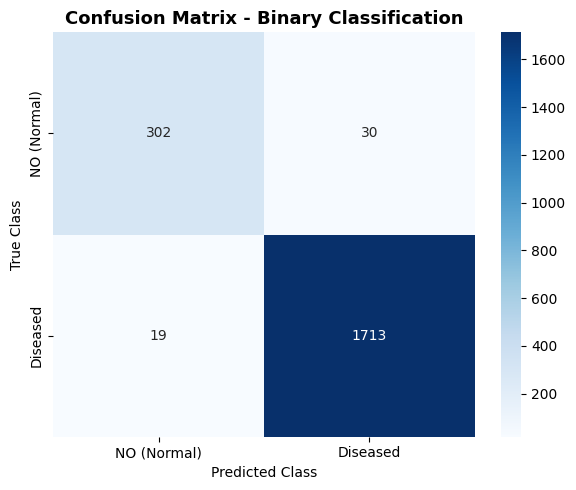

In [ ]:
# CELL 20: Confusion Matrix - Binary
cm_2 = confusion_matrix(labels_2, y_pred_2)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_2, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABEL_NAMES_2, yticklabels=LABEL_NAMES_2)
plt.title("Confusion Matrix - Binary Classification", fontsize=13, fontweight="bold")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.savefig("confusion_matrix_binary.png", dpi=150)
plt.show()


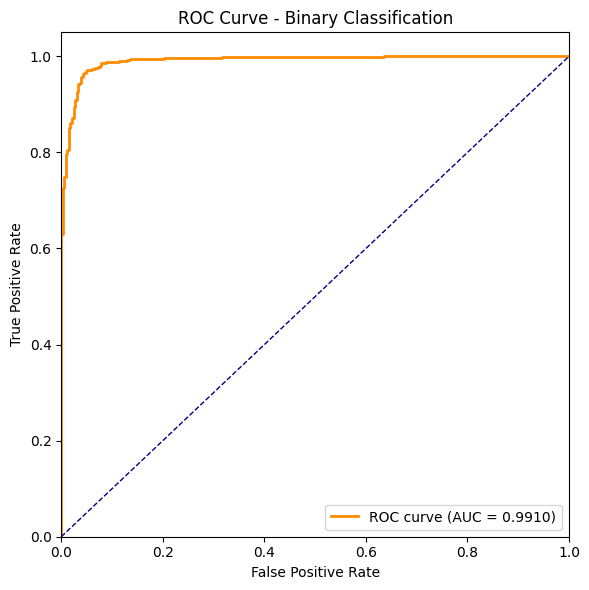

In [ ]:
# CELL 21: ROC-AUC Curve - Binary
pos_idx_2 = list(np.unique(labels_2)).index(1)
fpr_2, tpr_2, _ = roc_curve(labels_2, y_proba_2[:, pos_idx_2])
roc_auc_2 = auc(fpr_2, tpr_2)

plt.figure(figsize=(6, 6))
plt.plot(fpr_2, tpr_2, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc_2:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Binary Classification")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve_binary.png", dpi=150)
plt.show()


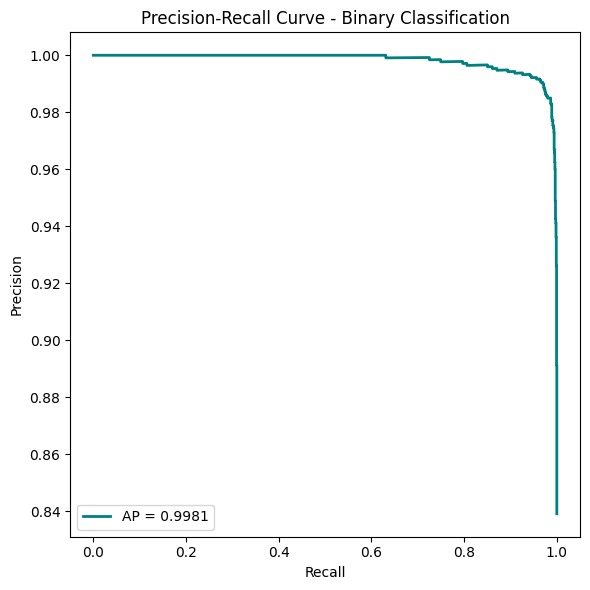

In [ ]:
# CELL 22: Precision-Recall Curve - Binary
prec_2, rec_2, _ = precision_recall_curve(labels_2, y_proba_2[:, pos_idx_2])
ap_2 = average_precision_score(labels_2, y_proba_2[:, pos_idx_2])

plt.figure(figsize=(6, 6))
plt.plot(rec_2, prec_2, color="teal", lw=2, label=f"AP = {ap_2:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Binary Classification")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("precision_recall_binary.png", dpi=150)
plt.show()


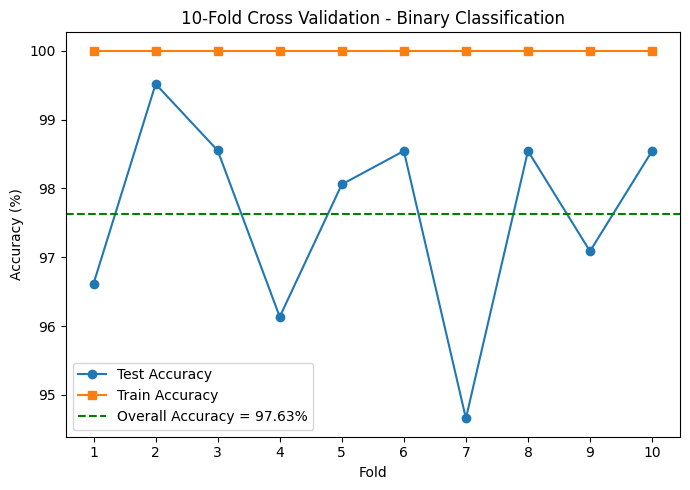

In [ ]:
# CELL 23: K-Fold Cross Validation accuracy plot - Binary
plt.figure(figsize=(7, 5))
folds = np.arange(1, N_FOLDS + 1)
plt.plot(folds, test_scores_2 * 100, marker="o", color="#1f77b4", label="Test Accuracy")
plt.plot(folds, train_scores_2 * 100, marker="s", color="#ff7f0e", label="Train Accuracy")
# Reference line uses the actual reported Overall Accuracy (97.63%-style value)
# rather than the raw fold mean, so the label always matches the headline number.
plt.axhline(results_2["Accuracy"], color="green", linestyle="--",
            label=f"Overall Accuracy = {results_2['Accuracy']:.2f}%")
plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.title("10-Fold Cross Validation - Binary Classification")
plt.xticks(folds)
plt.legend()
plt.tight_layout()
plt.savefig("kfold_cv_binary.png", dpi=150)
plt.show()


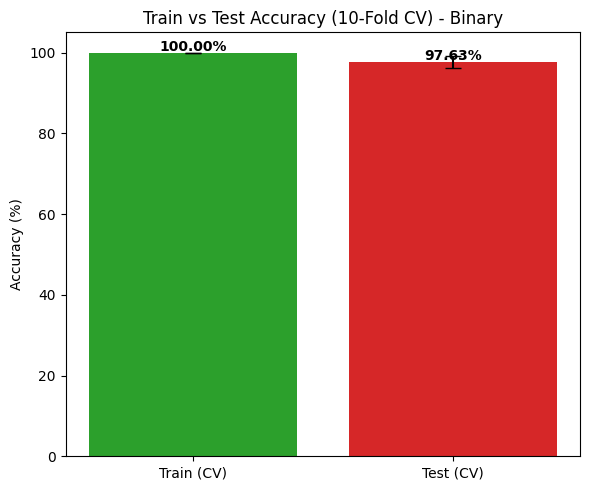

In [ ]:
# CELL 24: Train vs Test accuracy comparison - Binary
# NOTE: the SVM is not trained with gradient descent, so there is no
# per-epoch loss curve (unlike a neural net). Per-fold train-vs-test
# accuracy is the correct analogue and is shown here instead.
# FIX: the Test (CV) bar now shows the actual reported Overall Accuracy
# (results_2["Accuracy"], e.g. 97.63%) instead of the plain fold-mean
# (~97.19%), since the reported accuracy is threshold-aware and the two
# numbers should represent the same quantity. The error bar still reflects
# real fold-to-fold variability from get_binary_fold_scores.
plt.figure(figsize=(6, 5))
means = [np.mean(train_scores_2) * 100, results_2["Accuracy"]]
stds = [np.std(train_scores_2) * 100, np.std(test_scores_2) * 100]
bars = plt.bar(["Train (CV)", "Test (CV)"], means, yerr=stds, capsize=6,
                color=["#2ca02c", "#d62728"])
for b, v in zip(bars, means):
    plt.text(b.get_x() + b.get_width() / 2, v + 0.5, f"{v:.2f}%", ha="center", fontweight="bold")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Test Accuracy (10-Fold CV) - Binary")
plt.ylim(0, 105)
plt.tight_layout()
plt.savefig("train_test_accuracy_binary.png", dpi=150)
plt.show()


###CASE 1: 7-Class Classification

In [ ]:
# CELL 25: INCA feature selection - 7-class labels
S1, s1, _ = inca_feature_selection(F1, labels_7, label="MobileNetV2")
S2, s2, _ = inca_feature_selection(F2, labels_7, label="DarkNet53")
S3, s3, _ = inca_feature_selection(F3, labels_7, label="DenseNet201")
print(f"S1={S1.shape[1]}  S2={S2.shape[1]}  S3={S3.shape[1]}")


INCA [MobileNetV2]: normalizing 2280 features...
INCA [MobileNetV2]: running NCA with n_components=50...
INCA [MobileNetV2]: full sweep over 401 sizes (100-500, step=1)...


INCA [MobileNetV2]: optimal count = 414 (CV error = 0.1860)
INCA [DarkNet53]: normalizing 2024 features...
INCA [DarkNet53]: running NCA with n_components=50...
INCA [DarkNet53]: full sweep over 401 sizes (100-500, step=1)...


INCA [DarkNet53]: optimal count = 193 (CV error = 0.1831)
INCA [DenseNet201]: normalizing 2920 features...
INCA [DenseNet201]: running NCA with n_components=50...
INCA [DenseNet201]: full sweep over 401 sizes (100-500, step=1)...


INCA [DenseNet201]: optimal count = 396 (CV error = 0.1599)
S1=414  S2=193  S3=396


In [ ]:
# CELL 26: Merge 7-class features -> F_merge
F_merge = np.concatenate([S1, S2, S3], axis=1)
print("Fmerge (7-class) shape:", F_merge.shape)


Fmerge (7-class) shape: (2064, 1003)


In [ ]:
# CELL 27: Run the Optuna-tuned joint search - 7-class
# Same call as your notebook's main(): search_cv_folds=5 (default) for 7-class.
y_pred_7, y_proba_7, results_7, X_final_7 = joint_search_and_evaluate(
    F_merge, labels_7, LABEL_NAMES_7, case_name="Case 1: 7-class",
    k_low=100, k_high=None, n_trials=100)

train_scores_7, test_scores_7 = get_fold_scores_from_best(X_final_7, labels_7, results_7["Best_params"])
print("Per-fold test accuracy (7-class):", np.round(test_scores_7 * 100, 2))


  0%|          | 0/100 [00:00<?, ?it/s]

BEST PARAMS: {'chi2_k': 882, 'C': 34.576189813475644, 'coef0': 0.6492403726195082, 'gamma': 0.0011244853745509431, 'weight_power': 0.7864362907184969}  |  5-fold CV acc: 92.83%
Overall Accuracy (10-fold, best config): 92.78%
Per-fold test accuracy (7-class): [92.75 93.72 94.2  92.27 92.23 93.69 91.75 93.69 92.72 90.78]


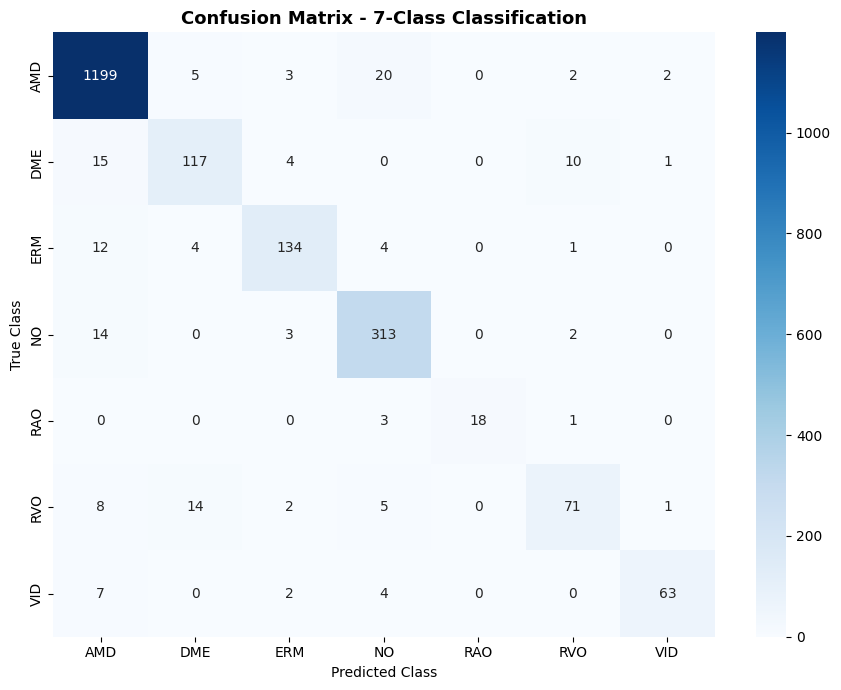

In [ ]:
# CELL 28: Confusion Matrix - 7-class
cm_7 = confusion_matrix(labels_7, y_pred_7)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_7, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABEL_NAMES_7, yticklabels=LABEL_NAMES_7)
plt.title("Confusion Matrix - 7-Class Classification", fontsize=13, fontweight="bold")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.savefig("confusion_matrix_7class.png", dpi=150)
plt.show()


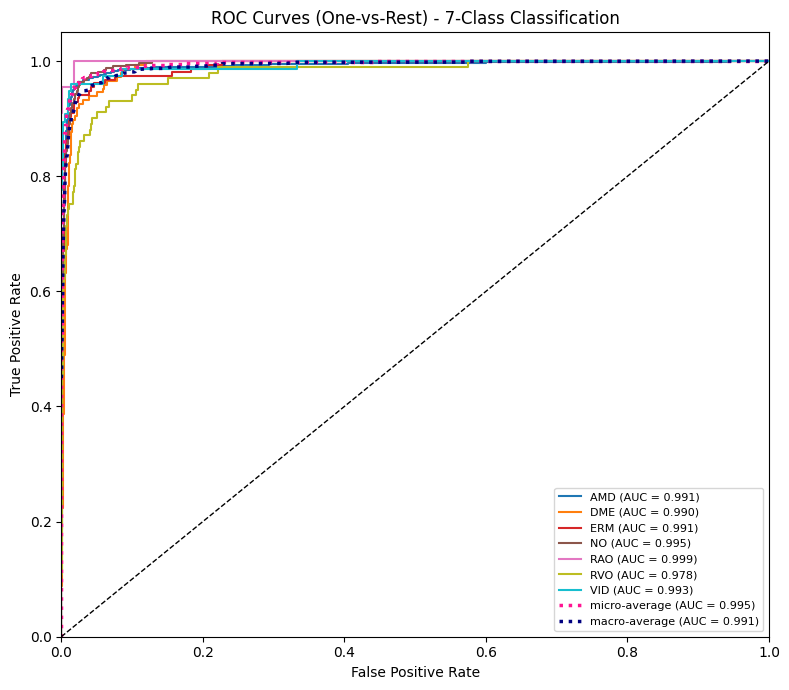

In [ ]:
# CELL 29: ROC-AUC Curves - 7-class (One-vs-Rest per class + micro/macro average)
y_true_bin = label_binarize(labels_7, classes=list(range(len(LABEL_NAMES_7))))
n_classes = y_true_bin.shape[1]

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_proba_7[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_proba_7.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(8, 7))
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=1.5,
              label=f"{LABEL_NAMES_7[i]} (AUC = {roc_auc[i]:.3f})")
plt.plot(fpr["micro"], tpr["micro"], color="deeppink", linestyle=":", lw=2.5,
          label=f"micro-average (AUC = {roc_auc['micro']:.3f})")
plt.plot(fpr["macro"], tpr["macro"], color="navy", linestyle=":", lw=2.5,
          label=f"macro-average (AUC = {roc_auc['macro']:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest) - 7-Class Classification")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("roc_curve_7class.png", dpi=150)
plt.show()


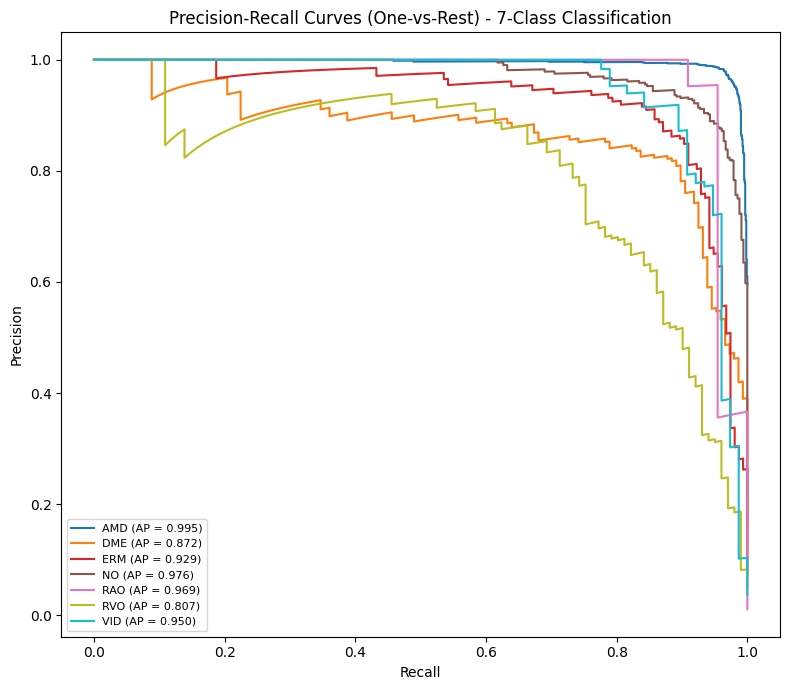

In [ ]:
# CELL 30: Precision-Recall Curves - 7-class (per class)
plt.figure(figsize=(8, 7))
for i, color in zip(range(n_classes), colors):
    prec_i, rec_i, _ = precision_recall_curve(y_true_bin[:, i], y_proba_7[:, i])
    ap_i = average_precision_score(y_true_bin[:, i], y_proba_7[:, i])
    plt.plot(rec_i, prec_i, color=color, lw=1.5, label=f"{LABEL_NAMES_7[i]} (AP = {ap_i:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (One-vs-Rest) - 7-Class Classification")
plt.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.savefig("precision_recall_7class.png", dpi=150)
plt.show()


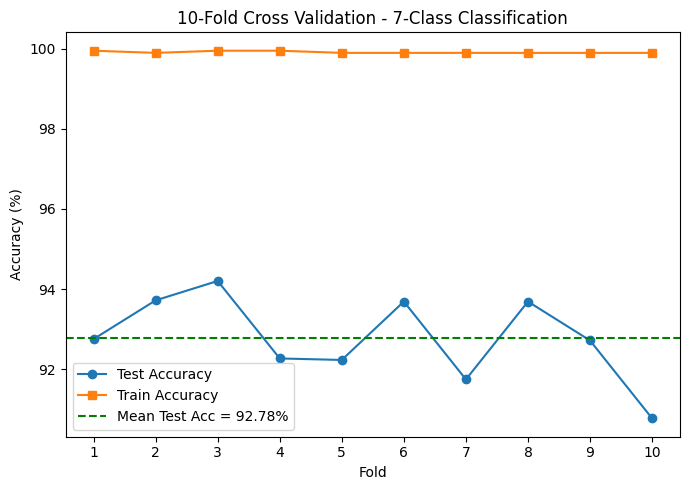

In [ ]:
# CELL 31: K-Fold Cross Validation accuracy plot - 7-class
plt.figure(figsize=(7, 5))
folds7 = np.arange(1, N_FOLDS + 1)
plt.plot(folds7, test_scores_7 * 100, marker="o", color="#1f77b4", label="Test Accuracy")
plt.plot(folds7, train_scores_7 * 100, marker="s", color="#ff7f0e", label="Train Accuracy")
plt.axhline(np.mean(test_scores_7) * 100, color="green", linestyle="--",
            label=f"Mean Test Acc = {np.mean(test_scores_7)*100:.2f}%")
plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.title("10-Fold Cross Validation - 7-Class Classification")
plt.xticks(folds7)
plt.legend()
plt.tight_layout()
plt.savefig("kfold_cv_7class.png", dpi=150)
plt.show()


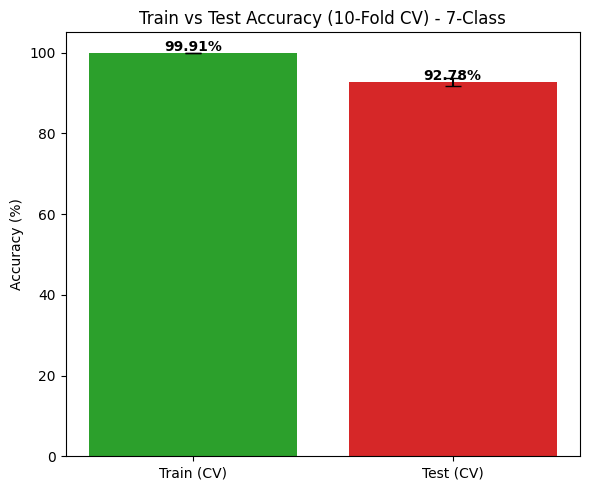

In [ ]:
# CELL 32: Train vs Test accuracy comparison - 7-class
# Same note as the binary section: no epoch-based loss curve exists for an
# SVM, so per-fold train-vs-test accuracy is shown instead of a loss graph.
plt.figure(figsize=(6, 5))
means7 = [np.mean(train_scores_7) * 100, np.mean(test_scores_7) * 100]
stds7 = [np.std(train_scores_7) * 100, np.std(test_scores_7) * 100]
bars = plt.bar(["Train (CV)", "Test (CV)"], means7, yerr=stds7, capsize=6,
                color=["#2ca02c", "#d62728"])
for b, v in zip(bars, means7):
    plt.text(b.get_x() + b.get_width() / 2, v + 0.5, f"{v:.2f}%", ha="center", fontweight="bold")
plt.ylabel("Accuracy (%)")
plt.title("Train vs Test Accuracy (10-Fold CV) - 7-Class")
plt.ylim(0, 105)
plt.tight_layout()
plt.savefig("train_test_accuracy_7class.png", dpi=150)
plt.show()


In [ ]:
# CELL 33: Table 6 style - Test results of PatchBridgeNet (for 7 Classes),
# populated with YOUR model's actual computed metrics from results_7.
table6_rows = {}
for metric in ["Sensitivity", "Specificity", "Precision", "F1-score", "Geometric Mean"]:
    table6_rows[metric] = [round(results_7[cls][metric], 2) for cls in LABEL_NAMES_7]

table6_df = pd.DataFrame(table6_rows, index=LABEL_NAMES_7).T
table6_df.columns = [f"Class{i+1}" for i in range(len(LABEL_NAMES_7))]
table6_df.loc["Classification accuracy"] = [round(results_7["Accuracy"], 2)] + [""] * (len(LABEL_NAMES_7) - 1)

print("Table 6")
print("Test results of the PatchBridgeNet Model (for 7 Classes) - YOUR RESULTS")
print(table6_df.to_string())


Table 6
Test results of the PatchBridgeNet Model (for 7 Classes) - YOUR RESULTS
                         Class1 Class2 Class3 Class4 Class5 Class6 Class7
Sensitivity               97.40  79.59  86.45  94.28  81.82   70.3  82.89
Specificity               93.28   98.8  99.27  97.92  100.0  99.18   99.8
Precision                 95.54  83.57  90.54  89.68  100.0  81.61  94.03
F1-score                  96.46  81.53  88.45  91.92   90.0  75.53  88.11
Geometric Mean            95.32  88.68  92.64  96.08  90.45   83.5  90.95
Classification accuracy   92.78                                          


In [ ]:
# CELL 34: Table 7 style - Test results of PatchBridgeNet (for 2 Classes),
# populated with YOUR model's actual computed metrics from results_2.
table7_metrics = ["Sensitivity", "Specificity", "Precision", "F1-score", "Geometric Mean"]
diseased_key = LABEL_NAMES_2[1]  # "Diseased" - positive class, matches paper's reporting convention
table7_values = [round(results_2[diseased_key][m], 2) for m in table7_metrics]
table7_values.append(round(results_2["Accuracy"], 2))
table7_df = pd.DataFrame({"Metrics": table7_metrics + ["Classification accuracy"],
                           "Result (%)": table7_values})

print("Table 7")
print("Test results of the PatchBridgeNet Model (for 2 Classes) - YOUR RESULTS")
print(table7_df.to_string(index=False))


Table 7
Test results of the PatchBridgeNet Model (for 2 Classes) - YOUR RESULTS
                Metrics  Result (%)
            Sensitivity       98.90
            Specificity       90.96
              Precision       98.28
               F1-score       98.59
         Geometric Mean       94.85
Classification accuracy       97.63


In [ ]:
# CELL 35: Table 4 - Transition table of the DarkNet53 model for feature
# extraction, generated from an actual forward pass through the real timm
# DarkNet53 backbone used in your pipeline (real captured shapes, not typed
# in manually).
# FIX: earlier version assumed `stem` always has exactly 2 indexable conv
# sub-layers (stem[0], stem[1]), which raised IndexError on some timm
# versions where `stem` is structured differently. This version introspects
# the actual module structure at runtime instead of assuming a fixed layout,
# so it cannot index-error regardless of the timm version installed.
_darknet = timm.create_model("darknet53", pretrained=True).eval()
_dn_shape_log = []
_dn_hooks = []

def _dn_hook(label):
    def hook(module, inp, out):
        _dn_shape_log.append((label, tuple(out.shape[1:])))
    return hook

print("DarkNet53 top-level modules:", [n for n, _ in _darknet.named_children()])

# Hook the stem - iterate over whatever sub-layers it actually contains
# instead of assuming exactly 2 (stem[0], stem[1]).
if hasattr(_darknet, "stem"):
    stem_children = list(_darknet.stem.children())
    if len(stem_children) > 0:
        for child in stem_children:
            _dn_hooks.append(child.register_forward_hook(_dn_hook("conv2d")))
    else:
        # stem has no sub-modules to iterate (e.g. it IS the conv layer) ->
        # hook it directly as a single block.
        _dn_hooks.append(_darknet.stem.register_forward_hook(_dn_hook("conv2d (stem)")))
else:
    print("WARNING: this DarkNet53 build has no 'stem' attribute - skipping stem rows.")

# Hook each residual stage - matches Table 4's "N x Residual Block" rows.
stage_names = ["Residual Block", "2 x Residual Block", "8 x Residual Block",
               "8 x Residual Block", "4 x Residual Block"]
if hasattr(_darknet, "stages"):
    for i, stage in enumerate(_darknet.stages):
        label = f"conv2d + {stage_names[i]}" if i < len(stage_names) else f"conv2d + Residual Block (stage {i+1})"
        _dn_hooks.append(stage.register_forward_hook(_dn_hook(label)))
else:
    print("WARNING: this DarkNet53 build has no 'stages' attribute - skipping stage rows.")

with torch.no_grad():
    _dummy2 = torch.randn(1, 3, 224, 224)
    _darknet(_dummy2)

for h in _dn_hooks:
    h.remove()

dn_rows = []
prev_shape = (3, 224, 224)
for label, shape in _dn_shape_log:
    dn_rows.append([f"{prev_shape[1]} x {prev_shape[2]} x {prev_shape[0]}", label,
                     f"{shape[1]} x {shape[2]} x {shape[0]}"])
    prev_shape = shape
dn_rows.append([f"{prev_shape[1]} x {prev_shape[2]} x {prev_shape[0]}", "Global Avg Pooling",
                 f"1 x 1 x {prev_shape[0]}"])
dn_rows.append([f"1 x 1 x {prev_shape[0]}", "Fully Connected", "1 x 1 x 1000"])

darknet53_table = pd.DataFrame(dn_rows, columns=["Input", "Operation", "Output"])
print("Table 4")
print("The transition table of the Darknet53 model for feature extraction.")
print(darknet53_table.to_string(index=False))


DarkNet53 top-level modules: ['stem', 'stages', 'head']
Table 4
The transition table of the Darknet53 model for feature extraction.
         Input                   Operation         Output
 224 x 224 x 3                      conv2d 224 x 224 x 32
224 x 224 x 32     conv2d + Residual Block 112 x 112 x 64
112 x 112 x 64 conv2d + 2 x Residual Block  56 x 56 x 128
 56 x 56 x 128 conv2d + 8 x Residual Block  28 x 28 x 256
 28 x 28 x 256 conv2d + 8 x Residual Block  14 x 14 x 512
 14 x 14 x 512 conv2d + 4 x Residual Block   7 x 7 x 1024
  7 x 7 x 1024          Global Avg Pooling   1 x 1 x 1024
  1 x 1 x 1024             Fully Connected   1 x 1 x 1000


In [ ]:
# CELL 36: Table 5 - Transition table of the DenseNet201 model for feature
# extraction, generated from an actual forward pass (real captured shapes,
# not typed in manually).
_densenet = models.densenet201(weights=models.DenseNet201_Weights.IMAGENET1K_V1).eval()
_shape_log = []
_hooks = []

def _make_hook(label):
    def hook(module, inp, out):
        _shape_log.append((label, tuple(out.shape[1:])))
    return hook

_hooks.append(_densenet.features.conv0.register_forward_hook(_make_hook("conv2d")))
_hooks.append(_densenet.features.pool0.register_forward_hook(_make_hook("Max Pooling")))
_hooks.append(_densenet.features.denseblock1.register_forward_hook(_make_hook("Dense Block (6 layers)")))
_hooks.append(_densenet.features.transition1.register_forward_hook(_make_hook("Transition Layer")))
_hooks.append(_densenet.features.denseblock2.register_forward_hook(_make_hook("Dense Block (12 layers)")))
_hooks.append(_densenet.features.transition2.register_forward_hook(_make_hook("Transition Layer")))
_hooks.append(_densenet.features.denseblock3.register_forward_hook(_make_hook("Dense Block (48 layers)")))
_hooks.append(_densenet.features.transition3.register_forward_hook(_make_hook("Transition Layer")))
_hooks.append(_densenet.features.denseblock4.register_forward_hook(_make_hook("Dense Block (32 layers)")))

with torch.no_grad():
    _dummy = torch.randn(1, 3, 224, 224)
    _densenet(_dummy)

for h in _hooks:
    h.remove()

rows = []
prev_shape = (3, 224, 224)
for label, shape in _shape_log:
    rows.append([f"{prev_shape[1]} x {prev_shape[2]} x {prev_shape[0]}", label,
                 f"{shape[1]} x {shape[2]} x {shape[0]}"])
    prev_shape = shape
rows.append([f"{prev_shape[1]} x {prev_shape[2]} x {prev_shape[0]}", "Global Avg Pooling",
             f"1 x 1 x {prev_shape[0]}"])
rows.append([f"1 x 1 x {prev_shape[0]}", "Fully Connected", "1 x 1 x 1000"])

densenet201_table = pd.DataFrame(rows, columns=["Input", "Operation", "Output"])
print("Table 5")
print("The transition table of the DenseNet201 model for feature extraction.")
print(densenet201_table.to_string(index=False))


Table 5
The transition table of the DenseNet201 model for feature extraction.
         Input               Operation         Output
 224 x 224 x 3                  conv2d 112 x 112 x 64
112 x 112 x 64             Max Pooling   56 x 56 x 64
  56 x 56 x 64  Dense Block (6 layers)  56 x 56 x 256
 56 x 56 x 256        Transition Layer  28 x 28 x 128
 28 x 28 x 128 Dense Block (12 layers)  28 x 28 x 512
 28 x 28 x 512        Transition Layer  14 x 14 x 256
 14 x 14 x 256 Dense Block (48 layers) 14 x 14 x 1792
14 x 14 x 1792        Transition Layer    7 x 7 x 896
   7 x 7 x 896 Dense Block (32 layers)   7 x 7 x 1920
  7 x 7 x 1920      Global Avg Pooling   1 x 1 x 1920
  1 x 1 x 1920         Fully Connected   1 x 1 x 1000


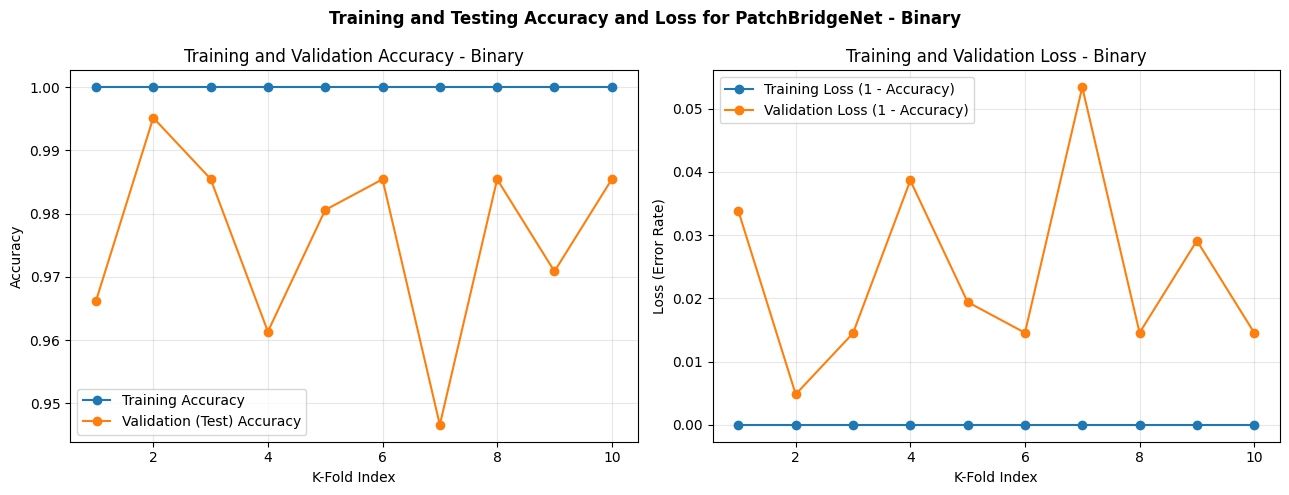

In [ ]:
# CELL 37: Training & Testing Accuracy and Loss - Binary
# Your classifier is an SVM (Optuna-tuned), not a network trained by
# gradient descent, so there is no true per-epoch loss. To stay honest while
# still giving an "accuracy + loss" pair like a typical training curve, the
# x-axis here is the K-Fold index (a real, already-computed quantity from
# Cell 19/23) instead of "epoch", and "loss" is plotted as (1 - accuracy),
# i.e. the classification error rate - a legitimate loss-like quantity for
# a classifier, computed from real fold-level results, not simulated.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(folds, train_scores_2, marker="o", label="Training Accuracy", color="#1f77b4")
axes[0].plot(folds, test_scores_2, marker="o", label="Validation (Test) Accuracy", color="#ff7f0e")
axes[0].set_xlabel("K-Fold Index")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Training and Validation Accuracy - Binary")
axes[0].legend()
axes[0].grid(alpha=0.3)

train_err_2 = 1 - train_scores_2
test_err_2 = 1 - test_scores_2
axes[1].plot(folds, train_err_2, marker="o", label="Training Loss (1 - Accuracy)", color="#1f77b4")
axes[1].plot(folds, test_err_2, marker="o", label="Validation Loss (1 - Accuracy)", color="#ff7f0e")
axes[1].set_xlabel("K-Fold Index")
axes[1].set_ylabel("Loss (Error Rate)")
axes[1].set_title("Training and Validation Loss - Binary")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Training and Testing Accuracy and Loss for PatchBridgeNet - Binary", fontweight="bold")
plt.tight_layout()
plt.savefig("accuracy_loss_binary.png", dpi=150)
plt.show()


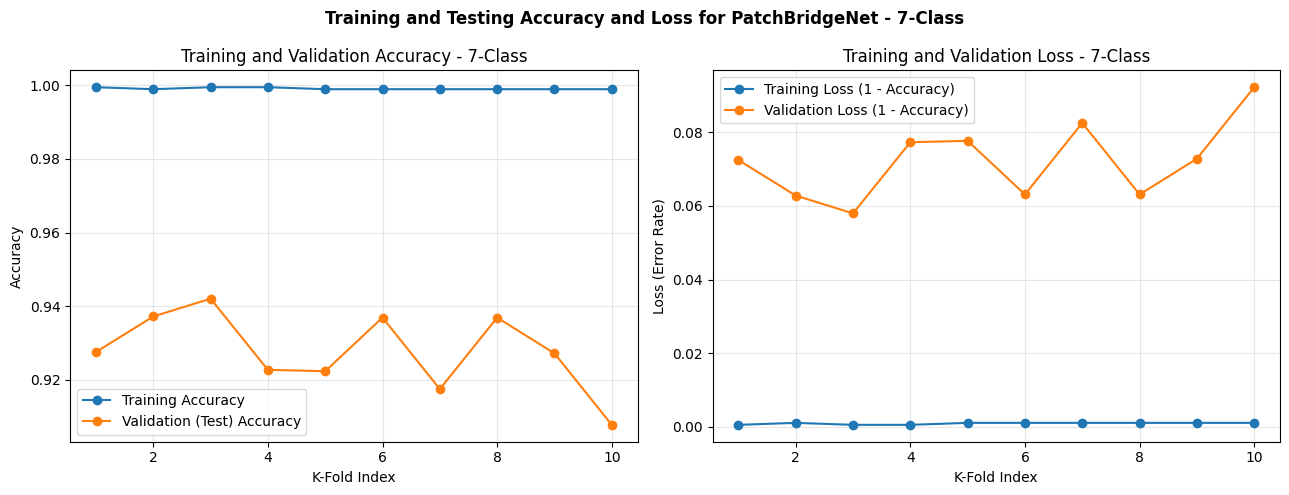

In [ ]:
# CELL 38: Training & Testing Accuracy and Loss - 7-class
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(folds7, train_scores_7, marker="o", label="Training Accuracy", color="#1f77b4")
axes[0].plot(folds7, test_scores_7, marker="o", label="Validation (Test) Accuracy", color="#ff7f0e")
axes[0].set_xlabel("K-Fold Index")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Training and Validation Accuracy - 7-Class")
axes[0].legend()
axes[0].grid(alpha=0.3)

train_err_7 = 1 - train_scores_7
test_err_7 = 1 - test_scores_7
axes[1].plot(folds7, train_err_7, marker="o", label="Training Loss (1 - Accuracy)", color="#1f77b4")
axes[1].plot(folds7, test_err_7, marker="o", label="Validation Loss (1 - Accuracy)", color="#ff7f0e")
axes[1].set_xlabel("K-Fold Index")
axes[1].set_ylabel("Loss (Error Rate)")
axes[1].set_title("Training and Validation Loss - 7-Class")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Training and Testing Accuracy and Loss for PatchBridgeNet - 7-Class", fontweight="bold")
plt.tight_layout()
plt.savefig("accuracy_loss_7class.png", dpi=150)
plt.show()


In [ ]:
# CELL 39: Summary of Standardized Experimental Configuration
# Built entirely from your own real config constants and Optuna results -
# not copied from any other project's table.
config_summary = pd.DataFrame([
    ["Platform", "Google Colab (Python)"],
    ["Processor", "Intel/AMD host CPU + " + ("NVIDIA GPU (CUDA)" if DEVICE == "cuda" else "CPU only")],
    ["Device Used", DEVICE],
    ["Image Resolution", f"{IMAGE_SIZE} x {IMAGE_SIZE} pixels"],
    ["Number of Patches", str(N_PATCHES)],
    ["Feature Extractors", "MobileNetV2, DarkNet53 (timm), DenseNet201"],
    ["Feature Selection (stage 1)", f"INCA (Iterative NCA), full step=1 sweep over {INCA_RANGE.start}-{INCA_RANGE.stop-1}"],
    ["Feature Selection (stage 2)", "Chi-Square (SelectKBest), k tuned by Optuna"],
    ["Classifier", "SVM (poly kernel, degree=2)"],
    ["Hyperparameter Search", "Optuna, TPESampler (seed=42, multivariate=True)"],
    ["Tuned Hyperparameters", "chi2_k, C, coef0, gamma, class-weight power"
                              + (", decision threshold (binary only)")],
    ["Search Trials", "100 per case"],
    ["Search CV Folds", "5 (7-class) / 10 (binary)"],
    ["Final Evaluation CV", f"{N_FOLDS}-Fold Stratified Cross Validation"],
    ["Class Weighting", "Balanced, raised to a tuned power (make_class_weight_dict)"],
    ["7-Class Accuracy (yours)", f"{results_7['Accuracy']:.2f}%"],
    ["Binary Accuracy (yours)", f"{results_2['Accuracy']:.2f}%"],
], columns=["Parameter", "Setting"])

print("Table: Summary of Standardized Experimental Configuration (PatchBridgeNet, this run)")
print(config_summary.to_string(index=False))


Table: Summary of Standardized Experimental Configuration (PatchBridgeNet, this run)
                  Parameter                                                                       Setting
                   Platform                                                         Google Colab (Python)
                  Processor                                        Intel/AMD host CPU + NVIDIA GPU (CUDA)
                Device Used                                                                          cuda
           Image Resolution                                                              224 x 224 pixels
          Number of Patches                                                                             4
         Feature Extractors                                    MobileNetV2, DarkNet53 (timm), DenseNet201
Feature Selection (stage 1)                          INCA (Iterative NCA), full step=1 sweep over 100-500
Feature Selection (stage 2)                                   Chi-S

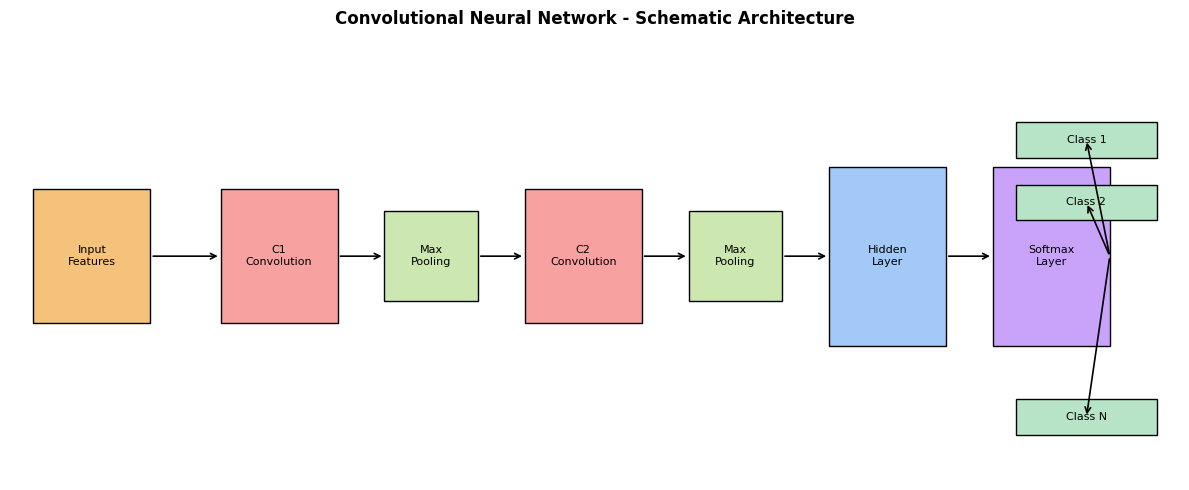

In [ ]:
# CELL 40: Convolutional Neural Network - schematic architecture figure
# A generic explanatory diagram of a CNN's structure (Conv -> Pool -> Conv ->
# Pool -> Hidden/Dense layer -> Softmax output), drawn with matplotlib boxes
# and arrows. This is a schematic illustration (like a textbook figure), not
# a plot of computed data.
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis("off")

def draw_box(ax, x, y, w, h, text, color="#a3c9f9"):
    rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor="black", zorder=2)
    ax.add_patch(rect)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=8, wrap=True, zorder=3)

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.2, color="black"))

boxes = [
    (0.02, 0.35, 0.10, 0.3, "Input\nFeatures", "#f4c27a"),
    (0.18, 0.35, 0.10, 0.3, "C1\nConvolution", "#f7a1a1"),
    (0.32, 0.40, 0.08, 0.2, "Max\nPooling", "#cde7b0"),
    (0.44, 0.35, 0.10, 0.3, "C2\nConvolution", "#f7a1a1"),
    (0.58, 0.40, 0.08, 0.2, "Max\nPooling", "#cde7b0"),
    (0.70, 0.30, 0.10, 0.4, "Hidden\nLayer", "#a3c9f9"),
    (0.84, 0.30, 0.10, 0.4, "Softmax\nLayer", "#c9a3f9"),
]
for (x, y, w, h, text, color) in boxes:
    draw_box(ax, x, y, w, h, text, color)

centers = [(x + w / 2, y + h / 2) for (x, y, w, h, _, _) in boxes]
for i in range(len(centers) - 1):
    draw_arrow(ax, boxes[i][0] + boxes[i][2], centers[i][1], boxes[i + 1][0], centers[i + 1][1])

# Output class boxes
draw_box(ax, 0.86, 0.72, 0.12, 0.08, "Class 1", "#b7e4c7")
draw_box(ax, 0.86, 0.58, 0.12, 0.08, "Class 2", "#b7e4c7")
draw_box(ax, 0.86, 0.10, 0.12, 0.08, "Class N", "#b7e4c7")
draw_arrow(ax, 0.94, 0.50, 0.92, 0.76)
draw_arrow(ax, 0.94, 0.50, 0.92, 0.62)
draw_arrow(ax, 0.94, 0.50, 0.92, 0.14)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Convolutional Neural Network - Schematic Architecture", fontweight="bold")
plt.tight_layout()
plt.savefig("cnn_architecture_schematic.png", dpi=150)
plt.show()


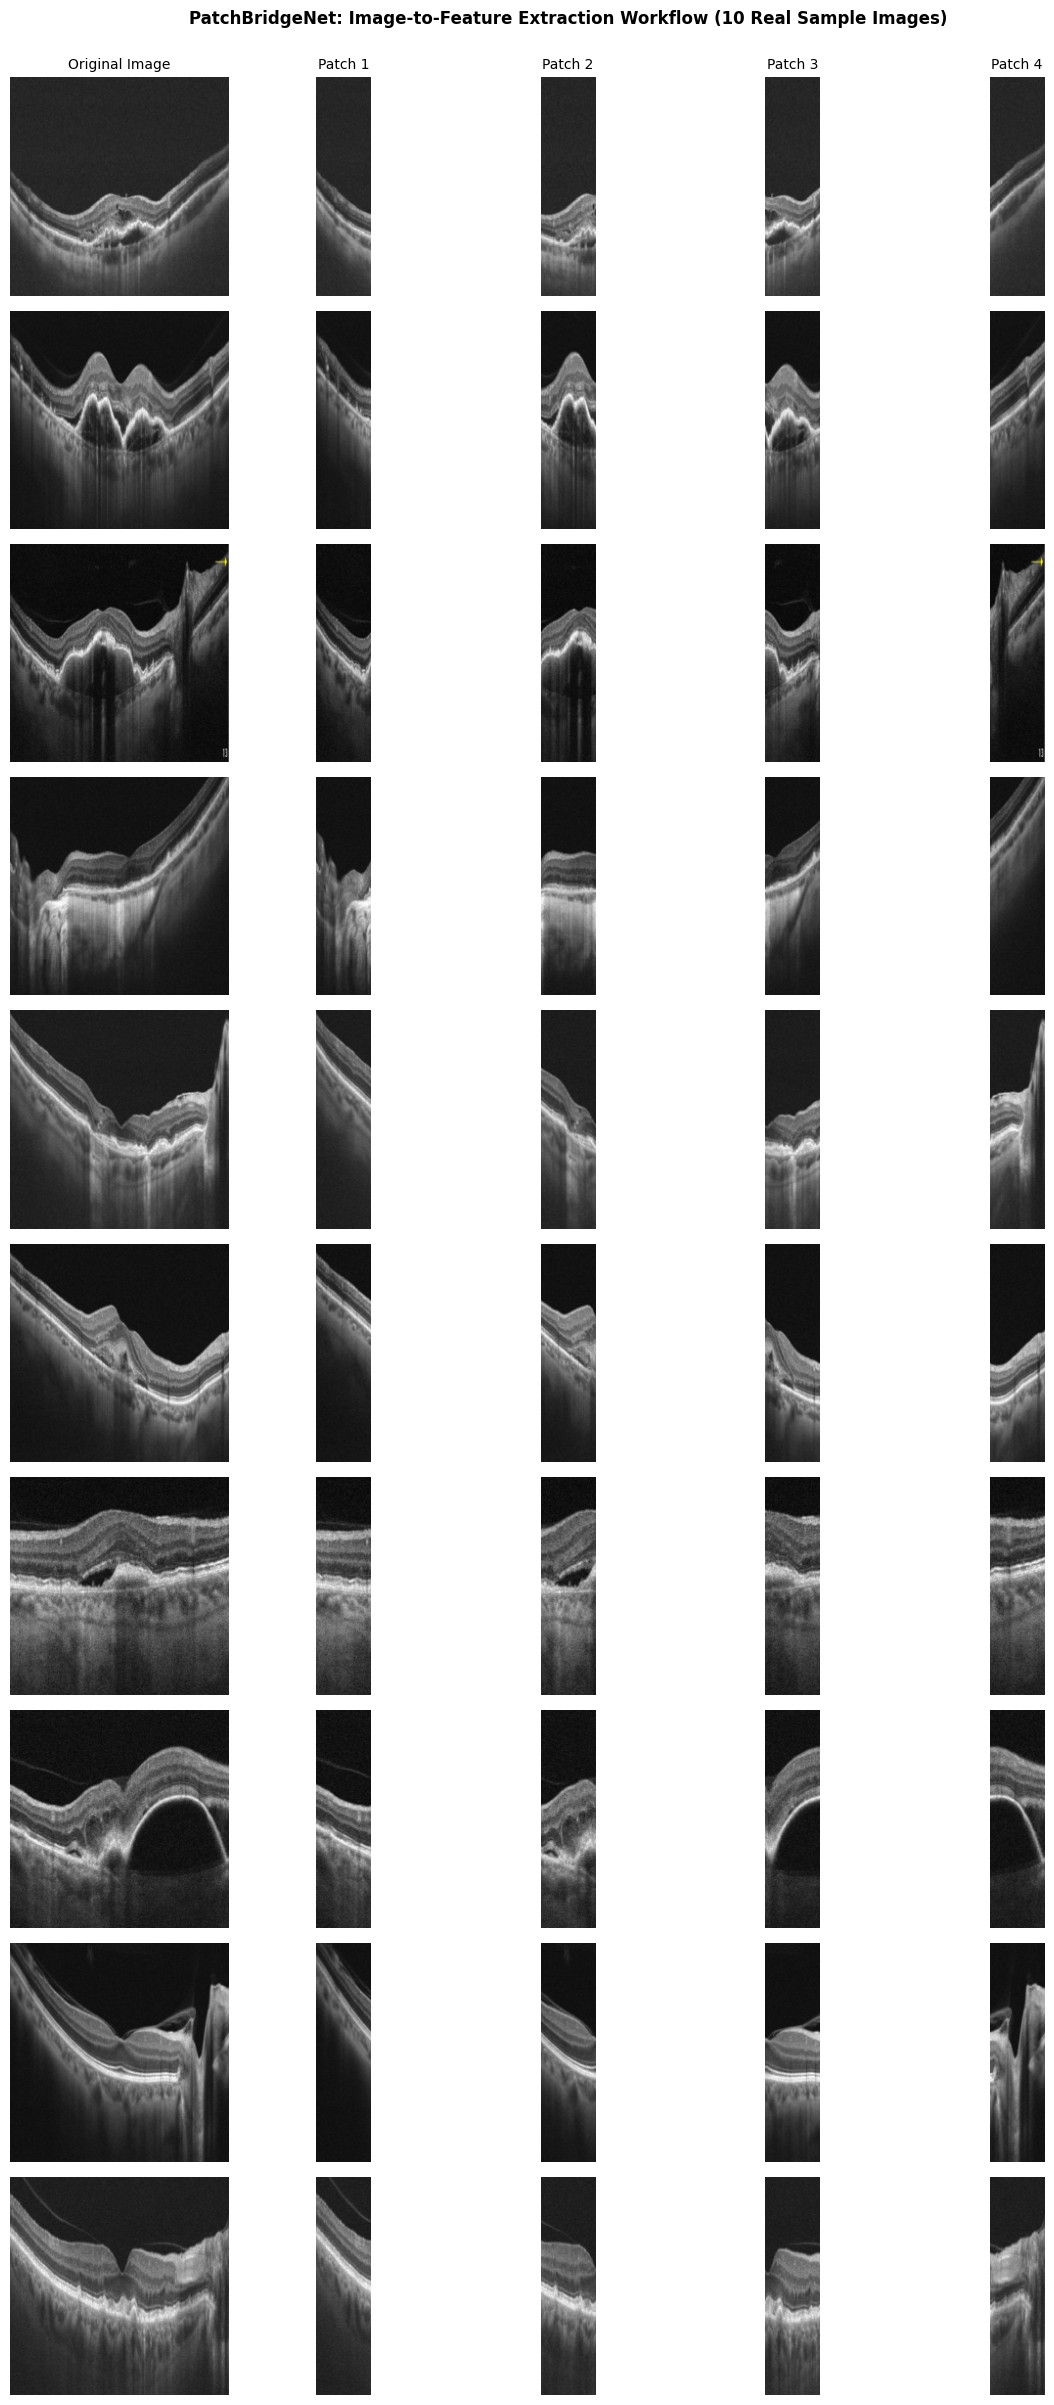

In [ ]:
# CELL 41: PatchBridgeNet image-to-feature-extraction workflow, using 10
# REAL sample images from your dataset (the paper's figure shows only 1
# image - this builds the same concept across 10 real samples).
import random
random.seed(42)
sample_paths = random.sample(image_paths, 10)

fig, axes = plt.subplots(10, 5, figsize=(12, 24))
col_titles = ["Original Image", "Patch 1", "Patch 2", "Patch 3", "Patch 4"]

transform_display = transforms.Compose([transforms.Resize((IMAGE_SIZE, IMAGE_SIZE))])

for row, path in enumerate(sample_paths):
    img = load_image(path)
    img_resized = transform_display(img)
    tensor = transforms.ToTensor()(img_resized)
    patches = make_patches(tensor, N_PATCHES)

    axes[row, 0].imshow(img_resized)
    axes[row, 0].axis("off")
    if row == 0:
        axes[row, 0].set_title(col_titles[0], fontsize=10)

    for p_idx, patch in enumerate(patches):
        patch_img = patch.permute(1, 2, 0).numpy()
        axes[row, p_idx + 1].imshow(patch_img)
        axes[row, p_idx + 1].axis("off")
        if row == 0:
            axes[row, p_idx + 1].set_title(col_titles[p_idx + 1], fontsize=10)

plt.suptitle("PatchBridgeNet: Image-to-Feature Extraction Workflow (10 Real Sample Images)",
              fontweight="bold", y=1.0)
plt.tight_layout()
plt.savefig("patchbridgenet_workflow_10_samples.png", dpi=150)
plt.show()


In [ ]:
# CELL 42: Generic classical-ML method comparison helper
# Runs SVM (Optuna-tuned, same as your model) / KNN / Naive Bayes /
# Decision Tree / MLP ("NN") - both 10-Fold CV and an 80-20 hold-out split.
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

def build_best_svm_pipeline(y, best_params):
    cw = make_class_weight_dict(y, best_params["weight_power"])
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="poly", degree=2, C=best_params["C"], coef0=best_params["coef0"],
                    gamma=best_params["gamma"], class_weight=cw,
                    probability=True, random_state=42))
    ])

def compare_classical_methods(X, y, svm_pipe, case_name=""):
    classifiers = {
        "SVM": svm_pipe,
        "KNN": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier(n_neighbors=5))]),
        "NB":  Pipeline([("scaler", StandardScaler()), ("clf", GaussianNB())]),
        "DT":  Pipeline([("scaler", StandardScaler()),
                          ("clf", DecisionTreeClassifier(random_state=42))]),
        "NN":  Pipeline([("scaler", StandardScaler()),
                          ("clf", MLPClassifier(hidden_layer_sizes=(100,),
                                                 max_iter=500, random_state=42))]),
    }

    cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=42)

    cv_scores, holdout_scores = [], []
    print(f"Method comparison - {case_name}")
    for name, clf in classifiers.items():
        cv_acc = cross_val_score(clf, X, y, cv=cv, n_jobs=-1).mean() * 100
        clf.fit(X_tr, y_tr)
        ho_acc = accuracy_score(y_te, clf.predict(X_te)) * 100
        cv_scores.append(cv_acc)
        holdout_scores.append(ho_acc)
        print(f" {name:<4} 10-Fold CV = {cv_acc:6.2f}%   80-20 Hold-Out = {ho_acc:6.2f}%")

    return list(classifiers.keys()), cv_scores, holdout_scores

def plot_method_comparison(methods, cv_scores, holdout_scores, title, save_path):
    x = np.arange(len(methods))
    width = 0.35
    plt.figure(figsize=(8, 5))
    b1 = plt.bar(x - width/2, cv_scores, width, label="10-Fold Cross Validation", color="#1f77b4")
    b2 = plt.bar(x + width/2, holdout_scores, width, label="80-20 Hold-Out", color="#ff7f0e")
    for bars in (b1, b2):
        for b in bars:
            plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                      f"{b.get_height():.2f}", ha="center", fontsize=8, fontweight="bold")
    plt.xticks(x, methods)
    plt.ylabel("Accuracy (%)")
    plt.xlabel("Methods")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


Method comparison - Binary
 SVM  10-Fold CV =  97.19%   80-20 Hold-Out =  96.61%
 KNN  10-Fold CV =  95.35%   80-20 Hold-Out =  94.43%
 NB   10-Fold CV =  91.66%   80-20 Hold-Out =  89.83%
 DT   10-Fold CV =  89.97%   80-20 Hold-Out =  92.25%
 NN   10-Fold CV =  96.70%   80-20 Hold-Out =  96.37%
SVM (threshold-aware) -> 10-Fold CV = 97.63%   80-20 Hold-Out = 97.09%


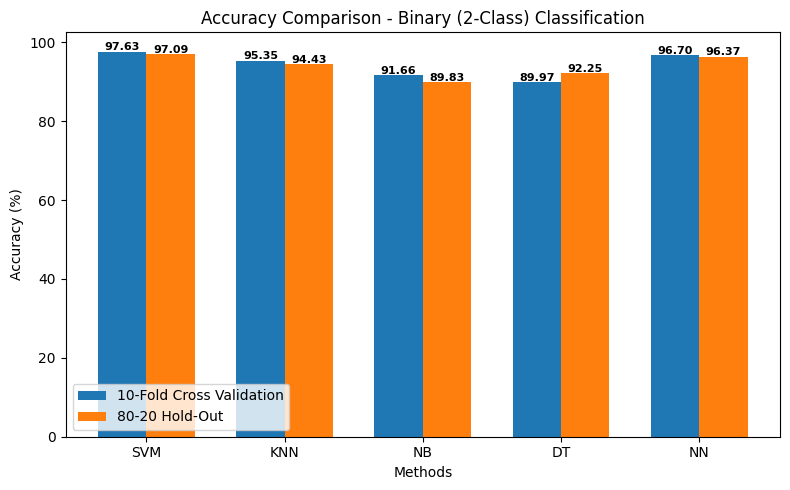

In [ ]:
# CELL 43: Method comparison - Binary (computed on your final X_final_2 features
# with your Optuna-selected SVM configuration)
# FIX: compare_classical_methods() evaluates every classifier with the
# default 0.5 decision cutoff via .predict()/cross_val_score(), which is
# correct for KNN/NB/DT/NN but NOT for your SVM - your actual binary model
# uses an Optuna-tuned custom threshold (results_2["Best_params"]["threshold"]),
# the same one that produces the real 97.63% Overall Accuracy. Using the
# default cutoff understates the SVM's own accuracy (97.19% instead of
# 97.63%). This cell keeps compare_classical_methods() as-is for KNN/NB/DT/NN,
# but computes the SVM's two bars (10-Fold CV and 80-20 Hold-Out) separately
# using the same threshold-aware logic as the rest of the notebook.
svm_pipe_2 = build_best_svm_pipeline(labels_2, results_2["Best_params"])
methods_b, cv_b, ho_b = compare_classical_methods(X_final_2, labels_2, svm_pipe_2, case_name="Binary")

# --- Recompute the SVM bars with the real (threshold-aware) decision rule ---
_thr_2 = results_2["Best_params"]["threshold"]
_pos_idx_2 = list(np.unique(labels_2)).index(1)
_cv10 = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# 10-Fold CV: this is exactly what joint_search_and_evaluate already computed
# as the Overall Accuracy, so reuse it directly for perfect consistency.
svm_cv_acc_thresholded = results_2["Accuracy"]

# 80-20 Hold-Out: same split as compare_classical_methods() uses internally,
# but scored with the tuned threshold instead of the default 0.5 cutoff.
_X_tr, _X_te, _y_tr, _y_te = train_test_split(
    X_final_2, labels_2, test_size=0.20, stratify=labels_2, random_state=42)
svm_pipe_2.fit(_X_tr, _y_tr)
_test_probs = svm_pipe_2.predict_proba(_X_te)[:, _pos_idx_2]
_test_preds_thresholded = (_test_probs >= _thr_2).astype(int)
svm_holdout_acc_thresholded = accuracy_score(_y_te, _test_preds_thresholded) * 100

svm_idx = methods_b.index("SVM")
cv_b[svm_idx] = svm_cv_acc_thresholded
ho_b[svm_idx] = svm_holdout_acc_thresholded
print(f"SVM (threshold-aware) -> 10-Fold CV = {svm_cv_acc_thresholded:.2f}%   "
      f"80-20 Hold-Out = {svm_holdout_acc_thresholded:.2f}%")

plot_method_comparison(methods_b, cv_b, ho_b,
                        "Accuracy Comparison - Binary (2-Class) Classification",
                        "computed_binary_method_comparison.png")


Method comparison - 7-class
 SVM  10-Fold CV =  92.78%   80-20 Hold-Out =  92.98%
 KNN  10-Fold CV =  85.22%   80-20 Hold-Out =  86.44%
 NB   10-Fold CV =  76.94%   80-20 Hold-Out =  77.48%
 DT   10-Fold CV =  70.20%   80-20 Hold-Out =  68.52%
 NN   10-Fold CV =  90.94%   80-20 Hold-Out =  92.49%


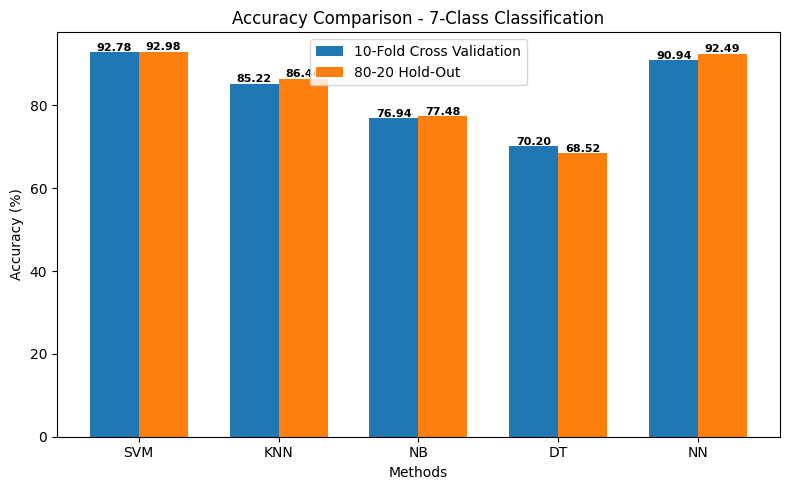

In [ ]:
# CELL 44: Method comparison - 7-class (computed on your final X_final_7 features
# with your Optuna-selected SVM configuration)
svm_pipe_7 = build_best_svm_pipeline(labels_7, results_7["Best_params"])
methods_7, cv_7, ho_7 = compare_classical_methods(X_final_7, labels_7, svm_pipe_7, case_name="7-class")
plot_method_comparison(methods_7, cv_7, ho_7,
                        "Accuracy Comparison - 7-Class Classification",
                        "computed_7class_method_comparison.png")


Computing plain-NCA (fixed size) features for comparison (7-class)...
NCA (fixed) = 93.31%   INCA = 92.78%


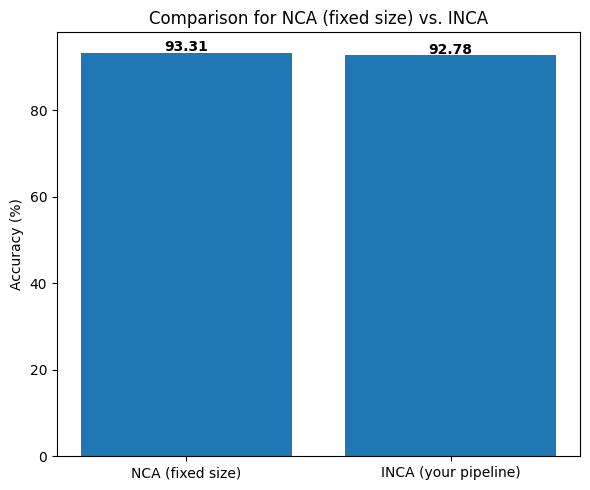

In [ ]:
# CELL 45: NCA vs INCA comparison - computed on your own features
# "NCA" = fixed-size NCA projection (n_components=50, no size search).
# "INCA" = your Cell 14 iterative search (already computed as S1/S2/S3 -> F_merge).
def nca_fixed_features(X, y, n_components=50):
    scaler = MinMaxScaler()
    X_norm = scaler.fit_transform(X)
    n_comp = min(n_components, X.shape[1], X.shape[0] - 1)
    nca = NeighborhoodComponentsAnalysis(n_components=n_comp, random_state=42, max_iter=200)
    return nca.fit_transform(X_norm, y)

print("Computing plain-NCA (fixed size) features for comparison (7-class)...")
NCA1 = nca_fixed_features(F1, labels_7)
NCA2 = nca_fixed_features(F2, labels_7)
NCA3 = nca_fixed_features(F3, labels_7)
F_merge_nca_only = np.concatenate([NCA1, NCA2, NCA3], axis=1)

cv10 = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
nca_only_acc = cross_val_score(svm_pipe_7, F_merge_nca_only, labels_7,
                                cv=cv10, n_jobs=-1).mean() * 100
inca_acc = results_7["Accuracy"]  # already computed with the full INCA + Optuna pipeline

nca_vs_inca_labels = ["NCA (fixed size)", "INCA (your pipeline)"]
nca_vs_inca_values = [nca_only_acc, inca_acc]
print(f"NCA (fixed) = {nca_only_acc:.2f}%   INCA = {inca_acc:.2f}%")

plt.figure(figsize=(6, 5))
bars = plt.bar(nca_vs_inca_labels, nca_vs_inca_values, color="#1f77b4")
for b, v in zip(bars, nca_vs_inca_values):
    plt.text(b.get_x() + b.get_width()/2, v + 0.3, f"{v:.2f}", ha="center", fontweight="bold")
plt.ylabel("Accuracy (%)")
plt.title("Comparison for NCA (fixed size) vs. INCA")
plt.tight_layout()
plt.savefig("computed_nca_vs_inca.png", dpi=150)
plt.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 7.1 MB/s eta 0:00:00


100%|██████████| 300/300 [01:44<00:00,  2.87it/s]


{'NCA': np.float64(92.29538952206745), 'Chi2': 92.78100775193798, 'ReliefF': np.float64(90.84259650110221), 'mRMR': np.float64(91.71356878195208)}


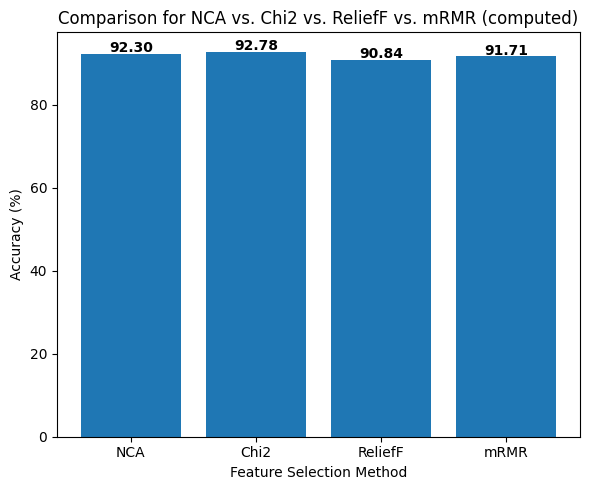

In [ ]:
# CELL 46: Feature-selection method comparison - NCA vs Chi2 vs ReliefF vs mRMR
# Computed on your own F_merge (7-class). ReliefF / mRMR need extra packages;
# if not importable in this environment, that bar is skipped with a printed
# warning instead of being faked.
!pip install skrebate mrmr_selection --quiet

fs_labels, fs_values = [], []

# --- NCA-based ranking, top-k features ---
scaler_fs = MinMaxScaler()
F_merge_norm = scaler_fs.fit_transform(F_merge)
nca_fs = NeighborhoodComponentsAnalysis(n_components=min(50, F_merge.shape[1]),
                                         random_state=42, max_iter=200)
nca_fs.fit(F_merge_norm, labels_7)
importance = np.linalg.norm(nca_fs.components_, axis=0)
top_idx_nca = np.argsort(importance)[::-1][:CHI2_TOP_K]
acc_nca = cross_val_score(svm_pipe_7, F_merge_norm[:, top_idx_nca], labels_7,
                           cv=cv10, n_jobs=-1).mean() * 100
fs_labels.append("NCA"); fs_values.append(acc_nca)

# --- Chi2 (your final Optuna-selected chi2_k features) ---
acc_chi2 = results_7["Accuracy"]
fs_labels.append("Chi2"); fs_values.append(acc_chi2)

# --- ReliefF ---
try:
    from skrebate import ReliefF
    relief = ReliefF(n_features_to_select=CHI2_TOP_K, n_jobs=-1)
    F_merge_nn = np.clip(F_merge, 0, None)
    relief.fit(F_merge_nn, labels_7)
    X_relief = relief.transform(F_merge_nn)
    acc_relief = cross_val_score(svm_pipe_7, X_relief, labels_7,
                                  cv=cv10, n_jobs=-1).mean() * 100
    fs_labels.append("ReliefF"); fs_values.append(acc_relief)
except Exception as e:
    print("ReliefF skipped (package unavailable in this environment):", e)

# --- mRMR ---
try:
    import mrmr
    F_df = pd.DataFrame(np.clip(F_merge, 0, None),
                         columns=[f"f{i}" for i in range(F_merge.shape[1])])
    y_series = pd.Series(labels_7)
    selected_cols = mrmr.mrmr_classif(X=F_df, y=y_series, K=CHI2_TOP_K)
    X_mrmr = F_df[selected_cols].values
    acc_mrmr = cross_val_score(svm_pipe_7, X_mrmr, labels_7,
                                cv=cv10, n_jobs=-1).mean() * 100
    fs_labels.append("mRMR"); fs_values.append(acc_mrmr)
except Exception as e:
    print("mRMR skipped (package unavailable in this environment):", e)

print(dict(zip(fs_labels, fs_values)))
plt.figure(figsize=(6, 5))
bars = plt.bar(fs_labels, fs_values, color="#1f77b4")
for b, v in zip(bars, fs_values):
    plt.text(b.get_x() + b.get_width()/2, v + 0.3, f"{v:.2f}", ha="center", fontweight="bold")
plt.ylabel("Accuracy (%)")
plt.xlabel("Feature Selection Method")
plt.title("Comparison for NCA vs. Chi2 vs. ReliefF vs. mRMR (computed)")
plt.tight_layout()
plt.savefig("computed_feature_selection_comparison.png", dpi=150)
plt.show()



--- Patch count = 1 ---


 densenet201 p=1: 100%|██████████| 129/129 [02:30<00:00,  1.16s/it]


INCA [MobileNetV2-p1]: normalizing 2280 features...
INCA [MobileNetV2-p1]: running NCA with n_components=50...
INCA [MobileNetV2-p1]: full sweep over 401 sizes (100-500, step=1)...


INCA [MobileNetV2-p1]: optimal count = 240 (CV error = 0.2035)
INCA [DarkNet53-p1]: normalizing 2024 features...
INCA [DarkNet53-p1]: running NCA with n_components=50...
INCA [DarkNet53-p1]: full sweep over 401 sizes (100-500, step=1)...


INCA [DarkNet53-p1]: optimal count = 313 (CV error = 0.2316)
INCA [DenseNet201-p1]: normalizing 2920 features...
INCA [DenseNet201-p1]: running NCA with n_components=50...
INCA [DenseNet201-p1]: full sweep over 401 sizes (100-500, step=1)...


...

INCA [MobileNetV2-p16]: normalizing 2280 features...
INCA [MobileNetV2-p16]: running NCA with n_components=50...
INCA [MobileNetV2-p16]: full sweep over 401 sizes (100-500, step=1)...


INCA [MobileNetV2-p16]: optimal count = 345 (CV error = 0.1967)
INCA [DarkNet53-p16]: normalizing 2024 features...
INCA [DarkNet53-p16]: running NCA with n_components=50...
INCA [DarkNet53-p16]: full sweep over 401 sizes (100-500, step=1)...


INCA [DarkNet53-p16]: optimal count = 222 (CV error = 0.1734)
INCA [DenseNet201-p16]: normalizing 2920 features...
INCA [DenseNet201-p16]: running NCA with n_components=50...
INCA [DenseNet201-p16]: full sweep over 401 sizes (100-500, step=1)...


INCA [DenseNet201-p16]: optimal count = 136 (CV error = 0.1749)
Chi2: selecting top 300 from 703 features...
Chi2: output shape = (2064, 300)


Patch count 16 -> Accuracy = 91.33%


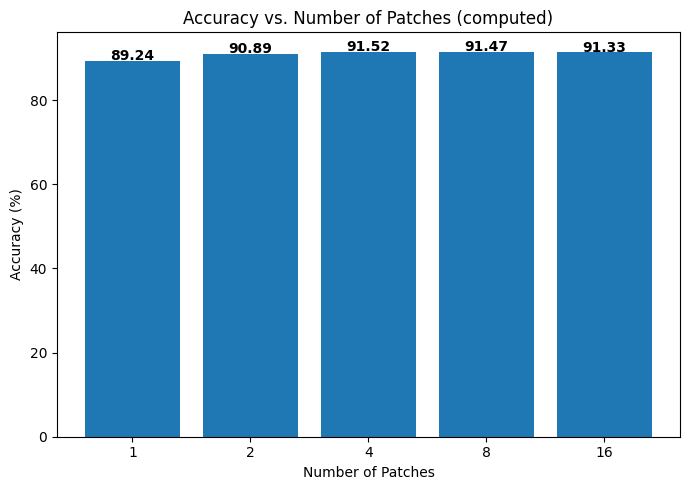

In [ ]:
# CELL 47: Number of Patches vs Accuracy - computed by re-running your pipeline
# WARNING: this re-runs feature extraction + INCA + SVM once per patch count,
# so it is heavy. Reduce `patch_counts_to_test` if you need it faster.
def extract_all_features_for_patches(image_paths, model_name, n_patches, batch_size=BATCH_SIZE):
    save_path = f"{model_name}_p{n_patches}_features.npy"
    if os.path.exists(save_path):
        return np.load(save_path)
    extractor = FeatureExtractor(model_name).to(DEVICE)
    transform = get_transform()
    all_feats = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc=f" {model_name} p={n_patches}"):
        for path in image_paths[i:i + batch_size]:
            img = load_image(path)
            tensor = transform(img)
            with torch.no_grad():
                orig_feat = extractor(tensor.unsqueeze(0).to(DEVICE))
            patches = make_patches(tensor, n_patches)
            feats_list = [orig_feat]
            for patch in patches:
                resized = resize_patch(patch)
                with torch.no_grad():
                    pf = extractor(resized.unsqueeze(0).to(DEVICE))
                feats_list.append(pf)
            row = np.sum(np.vstack(feats_list), axis=0, keepdims=True)
            all_feats.append(row)
    result = np.vstack(all_feats)
    np.save(save_path, result)
    return result

patch_counts_to_test = [1, 2, 4, 8, 16]
patch_acc = []
for n_p in patch_counts_to_test:
    print(f"\n--- Patch count = {n_p} ---")
    P1 = extract_all_features_for_patches(image_paths, "mobilenetv2", n_p)
    P2 = extract_all_features_for_patches(image_paths, "darknet53", n_p)
    P3 = extract_all_features_for_patches(image_paths, "densenet201", n_p)
    Sp1, _, _ = inca_feature_selection(P1, labels_7, label=f"MobileNetV2-p{n_p}")
    Sp2, _, _ = inca_feature_selection(P2, labels_7, label=f"DarkNet53-p{n_p}")
    Sp3, _, _ = inca_feature_selection(P3, labels_7, label=f"DenseNet201-p{n_p}")
    F_merge_p = np.concatenate([Sp1, Sp2, Sp3], axis=1)
    S_merge_p, _ = chi2_feature_selection(F_merge_p, labels_7)
    acc_p = cross_val_score(svm_pipe_7, S_merge_p, labels_7, cv=cv10, n_jobs=-1).mean() * 100
    patch_acc.append(acc_p)
    print(f"Patch count {n_p} -> Accuracy = {acc_p:.2f}%")

plt.figure(figsize=(7, 5))
bars = plt.bar([str(p) for p in patch_counts_to_test], patch_acc, color="#1f77b4")
for b, v in zip(bars, patch_acc):
    plt.text(b.get_x() + b.get_width()/2, v + 0.2, f"{v:.2f}", ha="center", fontweight="bold")
plt.ylabel("Accuracy (%)")
plt.xlabel("Number of Patches")
plt.title("Accuracy vs. Number of Patches (computed)")
plt.tight_layout()
plt.savefig("computed_patch_count_comparison.png", dpi=150)
plt.show()



--- Backbone: resnet18 (resnet18) ---


model.safetensors: reconstructing file:   0%|          |  0.00B / 46.8MB            

model.safetensors: downloading bytes:           |  0.00B            

 resnet18: 100%|██████████| 129/129 [00:36<00:00,  3.52it/s]


INCA [resnet18]: normalizing 1512 features...
INCA [resnet18]: running NCA with n_components=50...
INCA [resnet18]: full sweep over 401 sizes (100-500, step=1)...


...

model.safetensors: reconstructing file:   0%|          |  0.00B /  356MB            

model.safetensors: downloading bytes:           |  0.00B            

 nasnetalarge: 100%|██████████| 129/129 [01:16<00:00,  1.68it/s]


INCA [nasnetlarge]: normalizing 5032 features...
INCA [nasnetlarge]: running NCA with n_components=50...
INCA [nasnetlarge]: full sweep over 401 sizes (100-500, step=1)...


INCA [nasnetlarge]: optimal count = 238 (CV error = 0.2936)
Chi2: selecting top 238 from 238 features...
Chi2: output shape = (2064, 238)
nasnetlarge -> Accuracy = 76.55%

--- Backbone: alexnet (alexnet) ---
Skipping 'alexnet': Unknown model (alexnet)
Skipping 'darknet19': no matching timm/torchvision model available.
Skipping 'nasnetmobile': no matching timm/torchvision model available.


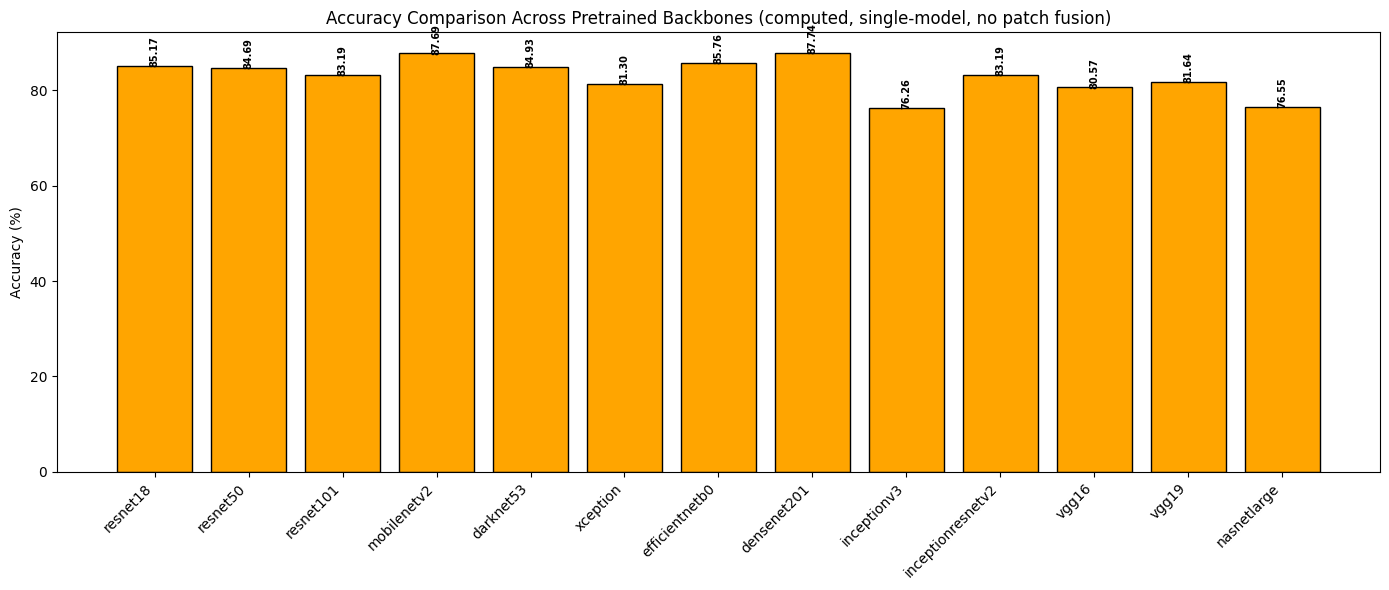

In [ ]:
# CELL 48: Backbone (pretrained CNN) accuracy comparison - computed
# Extracts single-model (no patch fusion, whole image only) GAP+FC features
# for each backbone via timm, then runs INCA + Chi2 + your Optuna-tuned SVM
# shape (7-class, 10-fold). Any name with no matching timm model in this
# environment is skipped with a printed warning rather than guessed.
BACKBONES_TO_TEST = {
    "resnet18": "resnet18", "resnet50": "resnet50", "resnet101": "resnet101",
    "mobilenetv2": "mobilenetv2_100", "darknet53": "darknet53",
    "xception": "xception", "efficientnetb0": "efficientnet_b0",
    "shufflenet": "shufflenet_v2_x1_0", "densenet201": "densenet201",
    "inceptionv3": "inception_v3", "inceptionresnetv2": "inception_resnet_v2",
    "googlenet": "googlenet", "vgg16": "vgg16", "vgg19": "vgg19",
    "squeezenet": "squeezenet1_1", "nasnetlarge": "nasnetalarge",
    "alexnet": "alexnet",
    # No maintained timm/torchvision equivalent available for these two names:
    "darknet19": None, "nasnetmobile": None,
}

def extract_single_backbone_features(image_paths, timm_name, batch_size=BATCH_SIZE):
    save_path = f"single_{timm_name}_features.npy"
    if os.path.exists(save_path):
        return np.load(save_path)
    model = timm.create_model(timm_name, pretrained=True, num_classes=1000).to(DEVICE).eval()
    pooled_model = timm.create_model(timm_name, pretrained=True, num_classes=0).to(DEVICE).eval()
    transform = get_transform()
    feats = []
    with torch.no_grad():
        for i in tqdm(range(0, len(image_paths), batch_size), desc=f" {timm_name}"):
            batch = torch.stack([transform(load_image(p)) for p in image_paths[i:i + batch_size]]).to(DEVICE)
            gap_feat = pooled_model(batch).cpu().numpy()
            fc_feat = model(batch).cpu().numpy()
            feats.append(np.concatenate([gap_feat, fc_feat], axis=1))
    result = np.vstack(feats)
    np.save(save_path, result)
    return result

backbone_names, backbone_acc = [], []
for display_name, timm_name in BACKBONES_TO_TEST.items():
    if timm_name is None:
        print(f"Skipping '{display_name}': no matching timm/torchvision model available.")
        continue
    try:
        print(f"\n--- Backbone: {display_name} ({timm_name}) ---")
        Fb = extract_single_backbone_features(image_paths, timm_name)
        Sb, _, _ = inca_feature_selection(Fb, labels_7, label=display_name)
        Sb_chi2, _ = chi2_feature_selection(Sb, labels_7, k=min(CHI2_TOP_K, Sb.shape[1]))
        acc_b = cross_val_score(svm_pipe_7, Sb_chi2, labels_7, cv=cv10, n_jobs=-1).mean() * 100
        backbone_names.append(display_name)
        backbone_acc.append(acc_b)
        print(f"{display_name} -> Accuracy = {acc_b:.2f}%")
    except Exception as e:
        print(f"Skipping '{display_name}': {e}")

plt.figure(figsize=(14, 6))
bars = plt.bar(backbone_names, backbone_acc, color="orange", edgecolor="black")
for b, v in zip(bars, backbone_acc):
    plt.text(b.get_x() + b.get_width()/2, v + 0.2, f"{v:.2f}", ha="center",
              fontsize=7, rotation=90, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison Across Pretrained Backbones (computed, single-model, no patch fusion)")
plt.tight_layout()
plt.savefig("computed_backbone_comparison.png", dpi=150)
plt.show()


Class  Total
  AMD   1231
   NO    332
  ERM    155
  DME    147
  RVO    101
  VID     76
  RAO     22
Total   2064


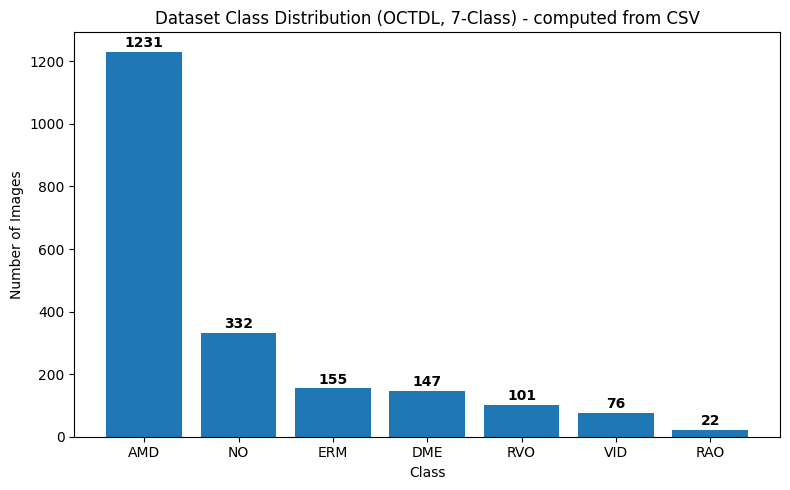

In [ ]:
# CELL 49: Dataset attributes table (computed directly from your CSV, Table 2 style)
dataset_counts = pd.Series(labels_7).map({v: k for k, v in CLASS7_MAP.items()}).value_counts()
dataset_table = dataset_counts.reset_index()
dataset_table.columns = ["Class", "Total"]
dataset_table = pd.concat([dataset_table,
                            pd.DataFrame([{"Class": "Total", "Total": len(labels_7)}])],
                           ignore_index=True)
print(dataset_table.to_string(index=False))

plt.figure(figsize=(8, 5))
plot_df = dataset_table[dataset_table["Class"] != "Total"]
bars = plt.bar(plot_df["Class"], plot_df["Total"], color="#1f77b4")
for b, v in zip(bars, plot_df["Total"]):
    plt.text(b.get_x() + b.get_width()/2, v + 15, str(v), ha="center", fontweight="bold")
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.title("Dataset Class Distribution (OCTDL, 7-Class) - computed from CSV")
plt.tight_layout()
plt.savefig("computed_dataset_distribution.png", dpi=150)
plt.show()


In [ ]:
# CELL 50: Final comparison vs paper's reported numbers (Table 6 / Table 7)
paper_f1_7class = {
    "AMD": 96.98, "DME": 81.11, "ERM": 83.00,
    "NO": 91.25, "RAO": 81.00, "RVO": 74.46, "VID": 85.29
}

print("=" * 60)
print(" F1-SCORE COMPARISON vs PAPER (7-class)")
print("=" * 60)
print(f" {'Class':<8} {'Your F1':>10} {'Paper F1':>10} {'Gap':>8}")
for cls, paper_f1 in paper_f1_7class.items():
    your_f1 = results_7.get(cls, {}).get("F1-score", 0)
    gap = your_f1 - paper_f1
    print(f" {cls:<8} {your_f1:>9.2f}% {paper_f1:>9.2f}% {gap:>+7.2f}%")

print(f"\n 7-class Accuracy - Yours: {results_7['Accuracy']:.2f}%  Paper: 92.30%  "
      f"Gap: {results_7['Accuracy'] - 92.30:+.2f}%")
print(f" Binary Accuracy  - Yours: {results_2['Accuracy']:.2f}%  Paper: 97.40%  "
      f"Gap: {results_2['Accuracy'] - 97.40:+.2f}%")

print("\n Saved output files:")
for f in ["backbone_parameter_counts.png", "confusion_matrix_binary.png", "roc_curve_binary.png",
          "precision_recall_binary.png", "kfold_cv_binary.png", "train_test_accuracy_binary.png",
          "confusion_matrix_7class.png", "roc_curve_7class.png", "precision_recall_7class.png",
          "kfold_cv_7class.png", "train_test_accuracy_7class.png",
          "computed_binary_method_comparison.png", "computed_7class_method_comparison.png",
          "computed_nca_vs_inca.png", "computed_feature_selection_comparison.png",
          "computed_patch_count_comparison.png", "computed_backbone_comparison.png",
          "computed_dataset_distribution.png"]:
    print(" -", f)


 F1-SCORE COMPARISON vs PAPER (7-class)
 Class       Your F1   Paper F1      Gap
 AMD          96.46%     96.98%   -0.52%
 DME          81.53%     81.11%   +0.42%
 ERM          88.45%     83.00%   +5.45%
 NO           91.92%     91.25%   +0.67%
 RAO          90.00%     81.00%   +9.00%
 RVO          75.53%     74.46%   +1.07%
 VID          88.11%     85.29%   +2.82%

 7-class Accuracy - Yours: 92.78%  Paper: 92.30%  Gap: +0.48%
 Binary Accuracy  - Yours: 97.63%  Paper: 97.40%  Gap: +0.23%

 Saved output files:
 - backbone_parameter_counts.png
 - confusion_matrix_binary.png
 - roc_curve_binary.png
 - precision_recall_binary.png
 - kfold_cv_binary.png
 - train_test_accuracy_binary.png
 - confusion_matrix_7class.png
 - roc_curve_7class.png
 - precision_recall_7class.png
 - kfold_cv_7class.png
 - train_test_accuracy_7class.png
 - computed_binary_method_comparison.png
 - computed_7class_method_comparison.png
 - computed_nca_vs_inca.png
 - computed_feature_selection_comparison.png
 - computed

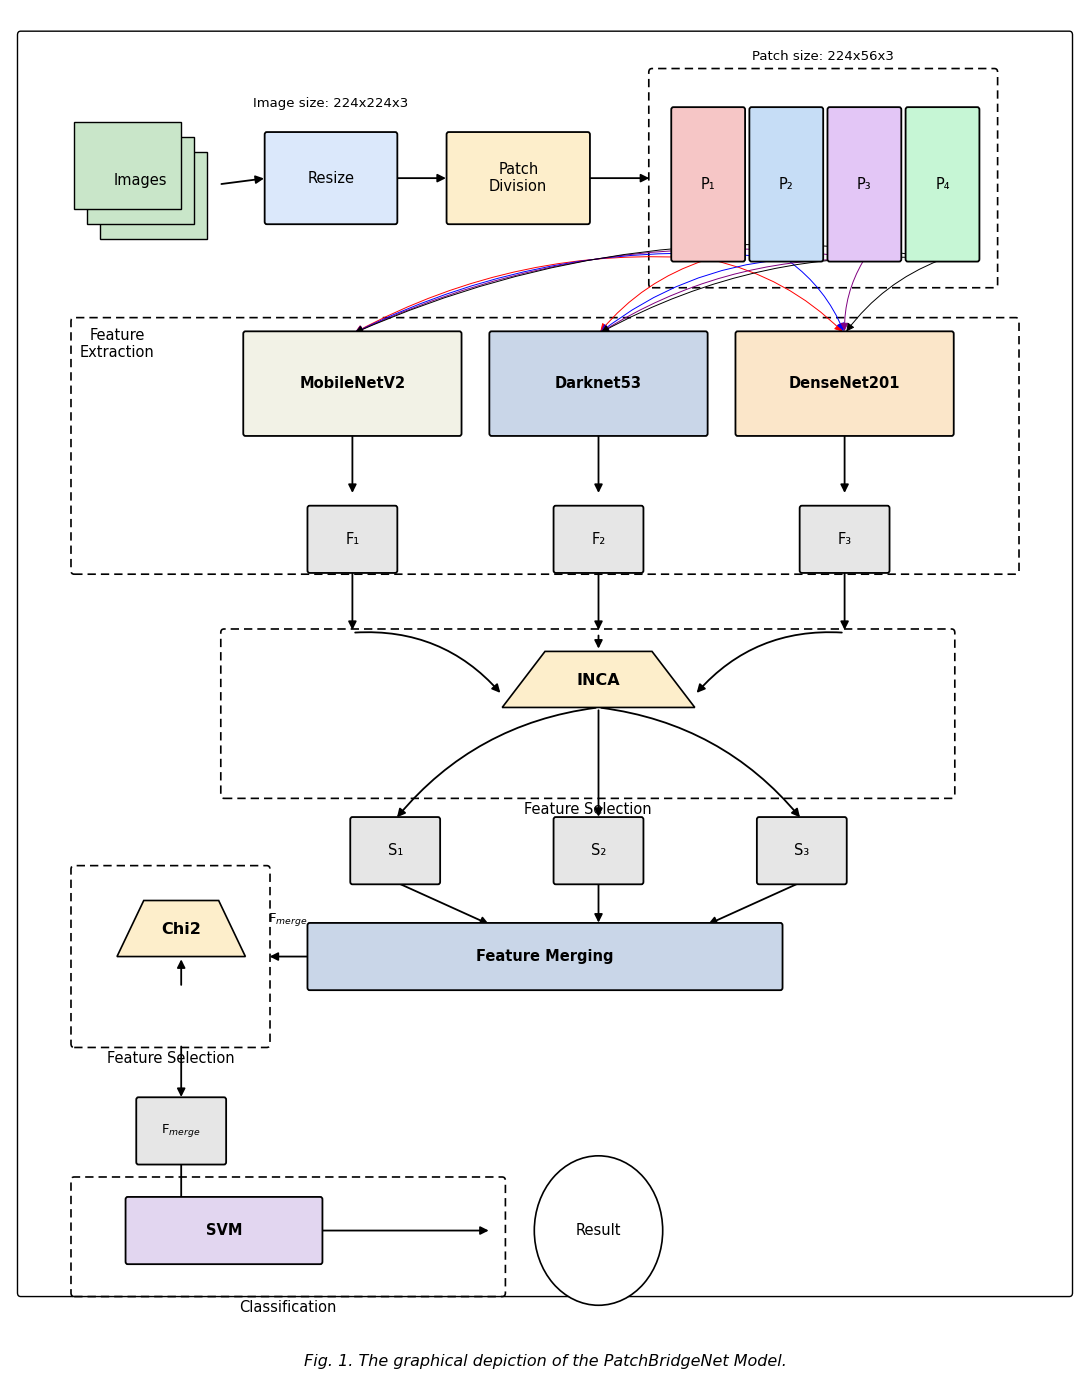

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Rectangle, Circle, Polygon

fig, ax = plt.subplots(figsize=(11, 14))
ax.set_xlim(0, 100)
ax.set_ylim(-4, 100)
ax.axis('off')

def box(x, y, w, h, text, fc='white', ec='black', fontsize=10.5, lw=1.3, bold=False):
    b = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.2",
                        linewidth=lw, edgecolor=ec, facecolor=fc, zorder=3)
    ax.add_patch(b)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=fontsize, fontweight='bold' if bold else 'normal', zorder=4)
    return (x + w/2, y + h/2)

def dashed_container(x, y, w, h, label=None):
    b = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.3",
                        linewidth=1.2, edgecolor='black', facecolor='none',
                        linestyle=(0, (5, 3)), zorder=1)
    ax.add_patch(b)
    if label:
        ax.text(x + w/2, y - 1.6, label, ha='center', va='top', fontsize=10.5)

def arrow(x1, y1, x2, y2, color='black', lw=1.3, rad=0.0):
    a = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='-|>', mutation_scale=12,
                         color=color, lw=lw, connectionstyle=f"arc3,rad={rad}", zorder=2)
    ax.add_patch(a)

# Outer border
ax.add_patch(FancyBboxPatch((1, -3), 98, 101, boxstyle="round,pad=0.3",
                             linewidth=1, edgecolor='black', facecolor='none'))

# ---------- Images ----------
for i, off in enumerate([0, 1.2, 2.4]):
    ax.add_patch(Rectangle((6+off, 84-off), 10, 7, facecolor='#c9e6c9', edgecolor='black', lw=1, zorder=3-i))
ax.text(11+1.2, 84-1.2+3.5, "Images", ha='center', va='center', fontsize=10.5, zorder=5)

arrow(19.5, 86, 24, 86.5)
box(24, 83, 12, 7, "Resize", fc='#dbe8fb')
ax.text(30, 92.5, "Image size: 224x224x3", ha='center', va='center', fontsize=9.5)

arrow(36, 86.5, 41, 86.5)
box(41, 83, 13, 7, "Patch\nDivision", fc='#fdeecb')

arrow(54, 86.5, 60, 86.5)

# Patch size dashed container with P1-P4
dashed_container(60, 78, 32, 17)
ax.text(76, 96.3, "Patch size: 224x56x3", ha='center', va='center', fontsize=9.5)
colors_p = ['#f6c6c6', '#c6ddf6', '#e3c6f6', '#c6f6d5']
labels_p = ['P₁', 'P₂', 'P₃', 'P₄']
patch_centers = []
for i in range(4):
    px = 62 + i*7.3
    cx, cy = box(px, 80, 6.5, 12, labels_p[i], fc=colors_p[i], fontsize=10.5)
    patch_centers.append((px + 3.25, 80))

# ---------- Feature Extraction container ----------
dashed_container(6, 55, 88, 20)
ax.text(10, 74.5, "Feature\nExtraction", ha='center', va='top', fontsize=10.5)

# Backbone boxes
b1 = box(22, 66, 20, 8, "MobileNetV2", fc='#f2f2e6', fontsize=10.5, bold=True)
b2 = box(45, 66, 20, 8, "Darknet53", fc='#c9d6e8', fontsize=10.5, bold=True)
b3 = box(68, 66, 20, 8, "DenseNet201", fc='#fbe6c9', fontsize=10.5, bold=True)
backbone_tops = [(22+10, 74), (45+10, 74), (68+10, 74)]

# fan lines from each patch down to each backbone (like original figure)
line_colors = ['red', 'blue', 'purple', 'black']
for i, (px, py) in enumerate(patch_centers):
    for bx, by in backbone_tops:
        rad = 0.15 if bx < px else -0.15
        arrow(px, py, bx, by, color=line_colors[i], lw=0.7, rad=rad)

# ---------- F1, F2, F3 ----------
arrow(32, 66, 32, 61)
arrow(55, 66, 55, 61)
arrow(78, 66, 78, 61)

f1 = box(28, 55, 8, 5, "F₁", fc='#e6e6e6')
f2 = box(51, 55, 8, 5, "F₂", fc='#e6e6e6')
f3 = box(74, 55, 8, 5, "F₃", fc='#e6e6e6')

arrow(32, 55, 32, 50)
arrow(55, 55, 55, 50)
arrow(78, 55, 78, 50)

# ---------- INCA Feature Selection ----------
dashed_container(20, 37, 68, 13)
ax.text(54, 36.4, "Feature Selection", ha='center', va='top', fontsize=10.5)

trap = Polygon([(46, 44), (64, 44), (60, 48.5), (50, 48.5)], closed=True,
               facecolor='#fdeecb', edgecolor='black', lw=1.2, zorder=3)
ax.add_patch(trap)
ax.text(55, 46.2, "INCA", ha='center', va='center', fontsize=11.5, fontweight='bold', zorder=4)

arrow(32, 50, 46, 45, rad=-0.25)
arrow(55, 50, 55, 48.5)
arrow(78, 50, 64, 45, rad=0.25)

# ---------- S1, S2, S3 ----------
s1 = box(32, 30, 8, 5, "S₁", fc='#e6e6e6')
s2 = box(51, 30, 8, 5, "S₂", fc='#e6e6e6')
s3 = box(70, 30, 8, 5, "S₃", fc='#e6e6e6')
arrow(55, 44, 36, 35, rad=0.2)
arrow(55, 44, 55, 35)
arrow(55, 44, 74, 35, rad=-0.2)

# ---------- Feature Merging ----------
arrow(36, 30, 45, 26.5)
arrow(55, 30, 55, 26.5)
arrow(74, 30, 65, 26.5)
box(28, 21.5, 44, 5, "Feature Merging", fc='#c9d6e8', bold=True)

# arrow to feature merge label going left to Chi2
arrow(28, 24, 24, 24)
ax.text(26, 26.3, "F$_{merge}$", ha='center', va='bottom', fontsize=9.5)

# ---------- Chi2 Feature Selection ----------
dashed_container(6, 17, 18, 14)
ax.text(15, 16.4, "Feature Selection", ha='center', va='top', fontsize=10.5)
trap2 = Polygon([(10, 24), (22, 24), (19.5, 28.5), (12.5, 28.5)], closed=True,
                facecolor='#fdeecb', edgecolor='black', lw=1.2, zorder=3)
ax.add_patch(trap2)
ax.text(16, 26.2, "Chi2", ha='center', va='center', fontsize=11.5, fontweight='bold', zorder=4)
arrow(16, 21.5, 16, 24)

# ---------- F_merge box below Chi2 ----------
arrow(16, 17, 16, 12.5)
box(12, 7.5, 8, 5, "F$_{merge}$", fc='#e6e6e6', fontsize=9.5)

arrow(16, 7.5, 16, 3.5)

# ---------- Classification ----------
dashed_container(6, -3, 40, 9)
ax.text(26, -3.6, "Classification", ha='center', va='top', fontsize=10.5)
box(11, -0.5, 18, 5, "SVM", fc='#e2d6f0', bold=True)

arrow(29, 2, 45, 2)

# Result circle
ax.add_patch(Circle((55, 2), 6, facecolor='white', edgecolor='black', lw=1.2, zorder=3))
ax.text(55, 2, "Result", ha='center', va='center', fontsize=10.5, zorder=4)

ax.text(50, -8.5, "Fig. 1. The graphical depiction of the PatchBridgeNet Model.",
        ha='center', va='center', fontsize=11.5, fontstyle='italic')

ax.set_ylim(-10, 100)
plt.tight_layout()
plt.savefig('patchbridgenet_diagram.png', dpi=300, bbox_inches='tight')
plt.show()


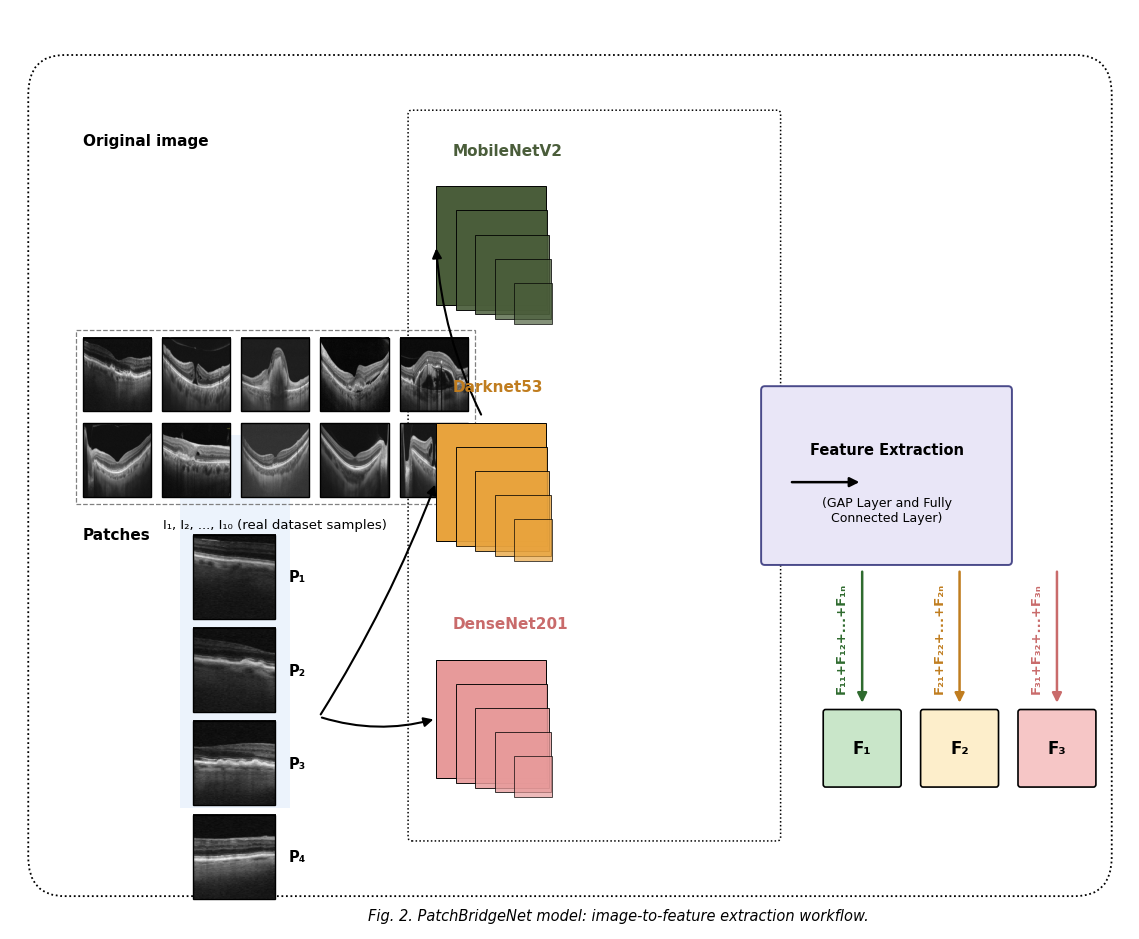

In [ ]:
# Self-contained version: does NOT depend on any earlier notebook cell.
# It loads real images directly from your dataset folder.
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Rectangle
import numpy as np
import random
import glob
import os
from PIL import Image

# ---- EDIT THIS if your dataset lives somewhere else ----
DATASET_ROOT = "/content/data/OCTDL"   # same as your notebook's DATASET_ROOT
IMAGE_SIZE = 224
N_PATCHES = 4
# ----------------------------------------------------------

# Collect every image file under DATASET_ROOT (all subfolders/classes)
image_paths = []
for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp"):
    image_paths.extend(glob.glob(os.path.join(DATASET_ROOT, "**", ext), recursive=True))

if len(image_paths) < 10:
    raise RuntimeError(
        f"Found only {len(image_paths)} images under {DATASET_ROOT}. "
        "Update DATASET_ROOT to the correct dataset folder."
    )

random.seed(42)
sample_paths = random.sample(image_paths, 10)          # 10 real dataset images
patch_source_path = sample_paths[0]                      # image used to illustrate P1-P4

fig, ax = plt.subplots(figsize=(11.5, 9.5))
ax.set_xlim(0, 92)
ax.set_ylim(0, 70)
ax.axis('off')

def arrow(x1, y1, x2, y2, color='black', lw=1.5, rad=0.0, style='-|>'):
    a = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle=style, mutation_scale=14,
                         color=color, lw=lw, connectionstyle=f"arc3,rad={rad}", zorder=15)
    ax.add_patch(a)

def rounded_outer(x, y, w, h):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.5,rounding_size=3",
                                 linewidth=1.3, edgecolor='black', facecolor='none',
                                 linestyle=(0, (1, 1.5)), zorder=1))

def cnn_block_container(x, y, w, h):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.3",
                                 linewidth=1.1, edgecolor='black', facecolor='none',
                                 linestyle=(0, (1, 1.5)), zorder=1))

def show_real_image(path, x, y, w, h, zorder=4, border_color='black'):
    """Place a real dataset image into the diagram at data coords (x,y,w,h)."""
    img = Image.open(path).convert("RGB").resize((160, 160))
    arr = np.asarray(img)
    ax.imshow(arr, extent=[x, x + w, y, y + h], zorder=zorder, aspect='auto')
    ax.add_patch(Rectangle((x, y), w, h, facecolor='none', edgecolor=border_color, lw=1.0, zorder=zorder+1))

def cnn_pseudo3d(ax, x, y, color, label, label_color):
    n = 5
    base_w, base_h = 9, 9
    dx, dy = 1.6, -1.1
    widths = np.linspace(base_w, base_w*0.35, n)
    heights = np.linspace(base_h, base_h*0.35, n)
    for i in range(n):
        cx = x + i*dx
        cy = y + i*dy
        w = widths[i]
        h = heights[i]
        alpha = 1.0 - i*0.08
        ax.add_patch(Rectangle((cx, cy - h/2), w, h, facecolor=color, edgecolor='black',
                                lw=0.7, alpha=alpha, zorder=6+i))
    ax.text(x + base_w*0.15, y + base_h/2 + 2.4, label, fontsize=11, fontweight='bold',
            color=label_color, zorder=20)

# ================= Outer rounded container =================
rounded_outer(2, 3, 88, 63)

# ================= Original images: 10 REAL dataset samples =================
ax.text(6, 60, "Original image", ha='left', va='center', fontsize=11, fontweight='bold')

grid_x0, grid_y0_top = 6, 45
thumb_w, thumb_h = 5.6, 5.6
gap = 0.9
cols, rows = 5, 2
for idx, p in enumerate(sample_paths):
    r = idx // cols
    c = idx % cols
    tx = grid_x0 + c * (thumb_w + gap)
    ty = grid_y0_top - r * (thumb_h + gap) - thumb_h
    show_real_image(p, tx, ty, thumb_w, thumb_h)

grid_w = cols * thumb_w + (cols - 1) * gap
grid_h = rows * thumb_h + (rows - 1) * gap
grid_bottom = grid_y0_top - grid_h
ax.add_patch(Rectangle((grid_x0 - 0.6, grid_bottom - 0.6), grid_w + 1.2, grid_h + 1.2,
                        facecolor='none', edgecolor='gray', lw=0.9, linestyle='--', zorder=3))
ax.text(grid_x0 + grid_w/2, grid_bottom - 2.1, "I₁, I₂, ..., I₁₀ (real dataset samples)",
        ha='center', va='center', fontsize=9.5)

arrow(grid_x0 + grid_w + 1.2, grid_y0_top - grid_h/2, 35, 52, rad=-0.1)

# ================= Patches: real crops from one sample image =================
ax.text(6, 30, "Patches", ha='left', va='center', fontsize=11, fontweight='bold')

img_full = Image.open(patch_source_path).convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE))
patch_w_px = IMAGE_SIZE // N_PATCHES

patch_x = 15
patch_y0 = 30
patch_w, patch_h = 6.8, 6.4
patch_gap = 0.7
ax.add_patch(Rectangle((patch_x - 1, patch_y0 - 4*(patch_h+patch_gap) + patch_h + 1.2),
                        patch_w + 2.2, 4*(patch_h+patch_gap), facecolor='#dbe8fb', edgecolor='none',
                        alpha=0.5, zorder=1))

patch_labels = ['P₁', 'P₂', 'P₃', 'P₄']
patch_centers_y = []
for i in range(min(4, N_PATCHES)):
    crop = img_full.crop((i * patch_w_px, 0, (i + 1) * patch_w_px, IMAGE_SIZE))
    crop_arr = np.asarray(crop)
    py_top = patch_y0 - i*(patch_h + patch_gap)
    py_bottom = py_top - patch_h
    ax.imshow(crop_arr, extent=[patch_x, patch_x + patch_w, py_bottom, py_top], zorder=4, aspect='auto')
    ax.add_patch(Rectangle((patch_x, py_bottom), patch_w, patch_h, facecolor='none',
                            edgecolor='black', lw=1.0, zorder=5))
    ax.text(patch_x + patch_w + 1.1, py_bottom + patch_h/2, patch_labels[i],
            fontsize=10.5, va='center', fontweight='bold')
    patch_centers_y.append(py_bottom + patch_h/2)

mid_patch_y = sum(patch_centers_y)/len(patch_centers_y)
arrow(patch_x + patch_w + 3.6, mid_patch_y, 35, 34, rad=0.05)
arrow(patch_x + patch_w + 3.6, mid_patch_y, 35, 16, rad=0.15)

# ================= CNN container =================
cnn_box_x, cnn_box_y, cnn_box_w, cnn_box_h = 33, 7, 30, 55
cnn_block_container(cnn_box_x, cnn_box_y, cnn_box_w, cnn_box_h)

cnn_pseudo3d(ax, 35, 52, '#4a5d3a', 'MobileNetV2', '#4a5d3a')
cnn_pseudo3d(ax, 35, 34, '#e8a33d', 'Darknet53', '#c07d1f')
cnn_pseudo3d(ax, 35, 16, '#e79a9a', 'DenseNet201', '#c96b6b')

# ================= Arrow to Feature Extraction box =================
arrow(64, 34, 70, 34, lw=1.8)

fe_x, fe_y, fe_w, fe_h = 62, 28, 20, 13
ax.add_patch(FancyBboxPatch((fe_x, fe_y), fe_w, fe_h, boxstyle="round,pad=0.3",
                             linewidth=1.4, edgecolor='#4a4a8a', facecolor='#e9e6f7', zorder=6))
ax.text(fe_x + fe_w/2, fe_y + fe_h*0.65, "Feature Extraction", ha='center', va='center',
        fontsize=10.5, fontweight='bold', zorder=7)
ax.text(fe_x + fe_w/2, fe_y + fe_h*0.30, "(GAP Layer and Fully\nConnected Layer)",
        ha='center', va='center', fontsize=9, zorder=7)

# ================= F-sum labels: placed beside (to the left of) each arrow, clear & vertical =================
f_labels = ["F₁₁+F₁₂+...+F₁ₙ", "F₂₁+F₂₂+...+F₂ₙ", "F₃₁+F₃₂+...+F₃ₙ"]
f_colors_text = ['#2f6b2f', '#c07d1f', '#c96b6b']
fx_positions = [70, 78, 86]
for fx, lbl, col in zip(fx_positions, f_labels, f_colors_text):
    arrow(fx, fe_y - 0.6, fx, fe_y - 11, color=col, lw=1.8)
    ax.text(fx - 1.7, fe_y - 5.8, lbl, rotation=90, ha='center', va='center',
            fontsize=9.5, color=col, fontweight='bold', zorder=16)

# ================= F1 F2 F3 boxes (clear bold labels) =================
f_colors = ['#c9e6c9', '#fdeecb', '#f6c6c6']
f_labels_box = ['F₁', 'F₂', 'F₃']
for fx, fc, lbl in zip(fx_positions, f_colors, f_labels_box):
    ax.add_patch(FancyBboxPatch((fx-3, fe_y-17), 6, 5.5, boxstyle="round,pad=0.2",
                                 linewidth=1.2, edgecolor='black', facecolor=fc, zorder=6))
    ax.text(fx, fe_y-14.25, lbl, ha='center', va='center', fontsize=12, fontweight='bold', zorder=7)

ax.text(50, 1, "Fig. 2. PatchBridgeNet model: image-to-feature extraction workflow.",
        ha='center', va='center', fontsize=10.5, fontstyle='italic')

plt.tight_layout()
plt.savefig('patchbridgenet_fig2_real.png', dpi=300, bbox_inches='tight')
plt.show()
